In [1]:
from src.processors.repd_processor import REPDProcessor
from datetime import datetime
from geopandas import gpd

In [2]:
processor = REPDProcessor()
df = processor.process_pipeline(date=datetime(2025,1,1))

Filtered by date: 2025-01-01 00:00:00, remaining records: 3195


/Users/dambem/Documents/code/repd_map/backend/src/processors/repd_processor.py:217: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/Users/dambem/Documents/code/repd_map/backend/src/processors/repd_processor.py:217: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/Users/dambem/Documents/code/repd_map/backend/src/processors/repd_processor.py:217: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/Users/dambem/Documents/code/repd_map/backend/src/processors/repd_processor.py:217: UserWarning: Parsing d

In [3]:
print(df)

      Old Ref ID  Ref ID Record Last Updated (dd/mm/yyyy)  \
0        N00053B       1                       2026-01-16   
901        AA664    1009                       2025-08-12   
2006       B0585    2470                       2025-12-02   
2009       C1830    2473                       2025-05-07   
2014       A0250    2484                       2026-01-19   
...          ...     ...                              ...   
13990        NaN   20234                       2026-01-19   
13991        NaN   20235                       2026-01-19   
13992        NaN   20236                       2026-01-19   
13993        NaN   20237                       2026-01-19   
13994        NaN   20239                       2026-01-19   

                     Operator (or Applicant)  \
0                                 RWE npower   
901     Fortum (formerly Peel Environmental)   
2006               Scottish Power Renewables   
2009           Orsted (formerly Dong Energy)   
2014               RWE Rene

In [4]:
df.to_csv('repd_data.csv', index=False)

In [5]:
df.geometry

0        POINT (-3.4066 51.3875)
901      POINT (-4.3565 55.8619)
2006       POINT (2.1728 52.137)
2009      POINT (1.4207 53.6815)
2014       POINT (2.552 52.6196)
                  ...           
13990     POINT (-2.829 53.2457)
13991     POINT (-1.2088 54.673)
13992    POINT (-2.7214 52.6972)
13993     POINT (-2.117 57.1079)
13994    POINT (-1.2509 54.5944)
Name: geometry, Length: 3179, dtype: geometry

In [6]:
df.to_csv('outputs/recent_projects.csv')

In [7]:
print(df['Development Status (short)'].unique())

<StringArray>
[             'Decommissioned',          'Under Construction',
       'Awaiting Construction',                 'Operational',
 'Planning Permission Expired',       'Application Submitted',
         'Application Refused',                     'Revised',
                   'Abandoned',            'Appeal Withdrawn',
       'Application Withdrawn',     'No Application Required']
Length: 12, dtype: str


In [8]:
from src.processors.repd_processor import UNSUCCESSFUL_DEVELOPMENT_TYPES, SUCCESSFUL_DEVELOPMENT_TYPES, NEUTRAL_DEVELOPMENT_TYPES

In [9]:
df_unsuccesful = df[df['Development Status (short)'].isin(UNSUCCESSFUL_DEVELOPMENT_TYPES)]
df_succesful = df[df['Development Status (short)'].isin(SUCCESSFUL_DEVELOPMENT_TYPES)]
df_neutral = df[df['Development Status (short)'].isin(['Application Submitted'])]
df_awaiting = df[df['Development Status (short)'].isin(['Awaiting Construction'])]


In [10]:
print(len(df_unsuccesful))
print(len(df_succesful))
print(len(df_neutral))
print(len(df_awaiting))

243
141
1037
1702


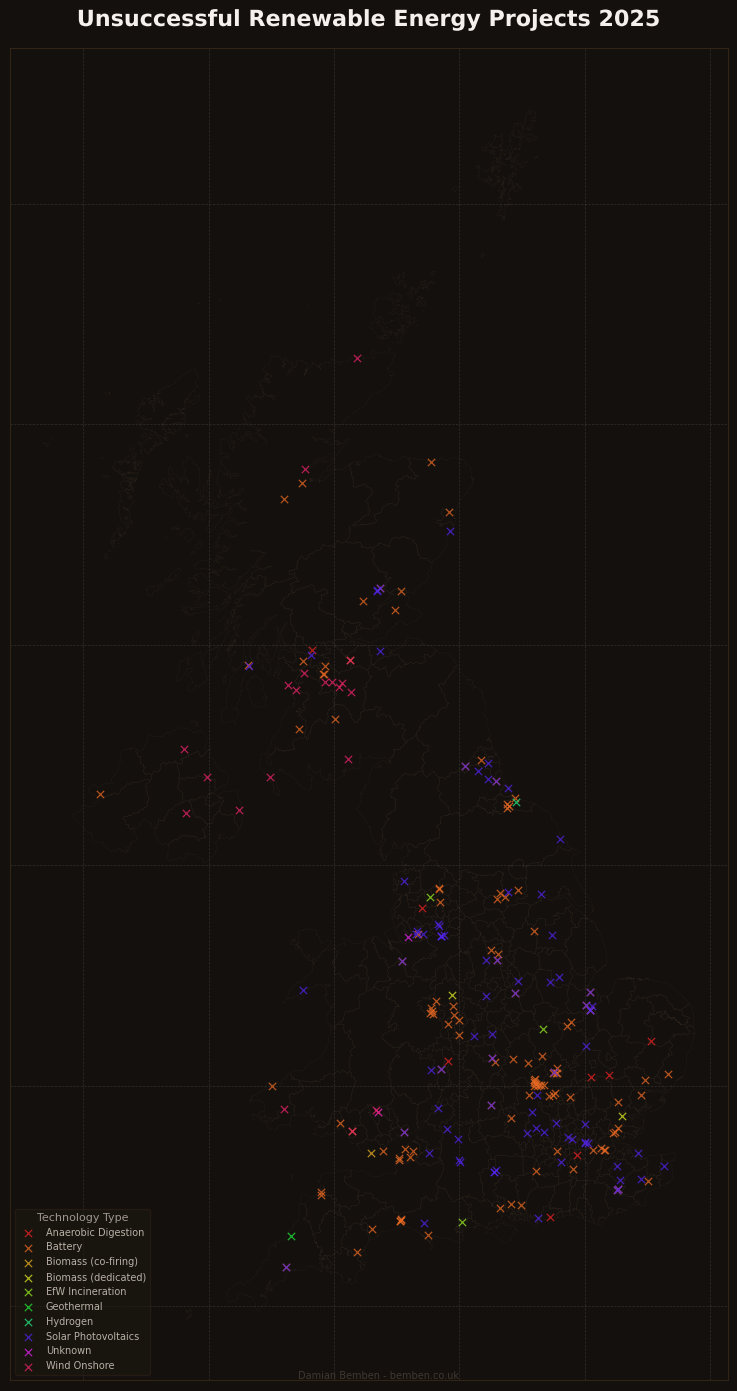

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import numpy as np
import geopandas as gpd

lauth = gpd.read_file("src/data/localauth.json")

all_tech_types = sorted(df["Technology Type"].dropna().unique())
n      = len(all_tech_types)
colors = {tech: mcolors.hsv_to_rgb((i / n, 0.85, 0.92)) for i, tech in enumerate(all_tech_types)}

fig, ax = plt.subplots(figsize=(10, 14), facecolor="#13100d")
ax.set_facecolor("#13100d")

lauth.plot(ax=ax, facecolor="none", edgecolor="#6b5040", linewidth=0.3, alpha=0.2, zorder=1)

for tech, group in df_unsuccesful.groupby("Technology Type"):
    ax.scatter(group.geometry.x, group.geometry.y, c=[colors[tech]],
               marker="x", s=28, linewidths=0.9, alpha=0.75, label=tech, zorder=3)

ax.grid(color="#ffffff", alpha=0.12, linewidth=0.5, linestyle="--")
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor("#332418")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_title("Unsuccessful Renewable Energy Projects 2025", fontsize=16, fontweight="bold",
             color="#f5f0eb", pad=16, path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")])
legend = ax.legend(title="Technology Type", loc="lower left", fontsize=7, title_fontsize=8,
                   framealpha=0.5, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")
legend.get_title().set_color("#a09890")
fig.text(0.59, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


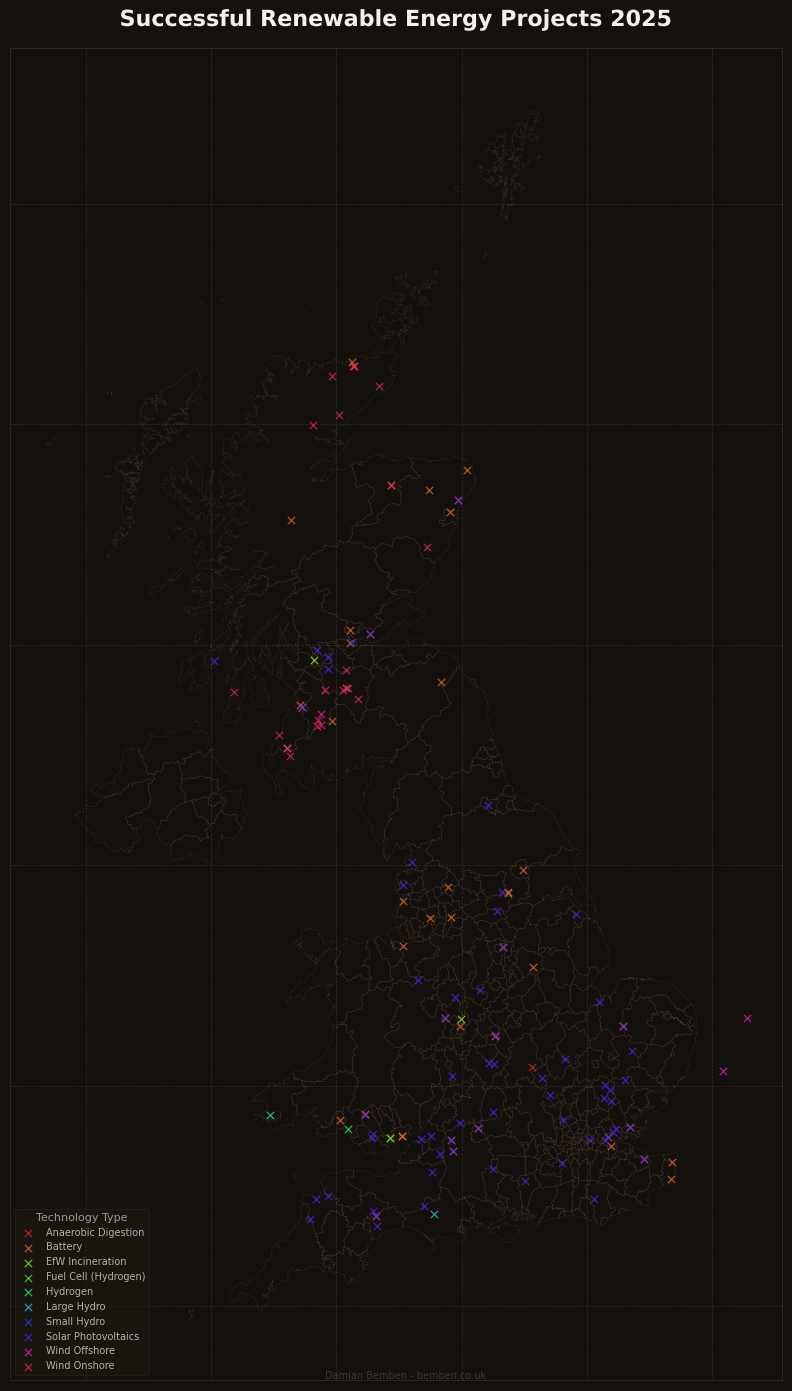

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import numpy as np
import geopandas as gpd

lauth = gpd.read_file("src/data/localauth.json")

all_tech_types = sorted(df["Technology Type"].dropna().unique())
n      = len(all_tech_types)
colors = {tech: mcolors.hsv_to_rgb((i / n, 0.85, 0.92)) for i, tech in enumerate(all_tech_types)}

fig, ax = plt.subplots(figsize=(10, 14), facecolor="#13100d")
ax.set_facecolor("#13100d")

lauth.plot(ax=ax, facecolor="none", edgecolor="#c89679", linewidth=0.3, alpha=0.2, zorder=1)

for tech, group in df_succesful.groupby("Technology Type"):
    ax.scatter(group.geometry.x, group.geometry.y, c=[colors[tech]],
               marker="x", s=28, linewidths=0.9, alpha=0.75, label=tech, zorder=3)

ax.grid(color="#ffffff", alpha=0.12, linewidth=0.5, linestyle="--")
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor("#332418")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_title("Successful Renewable Energy Projects 2025", fontsize=16, fontweight="bold",
             color="#f5f0eb", pad=16, path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")])
legend = ax.legend(title="Technology Type", loc="lower left", fontsize=7, title_fontsize=8,
                   framealpha=0.5, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")
legend.get_title().set_color("#a09890")
fig.text(0.59, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


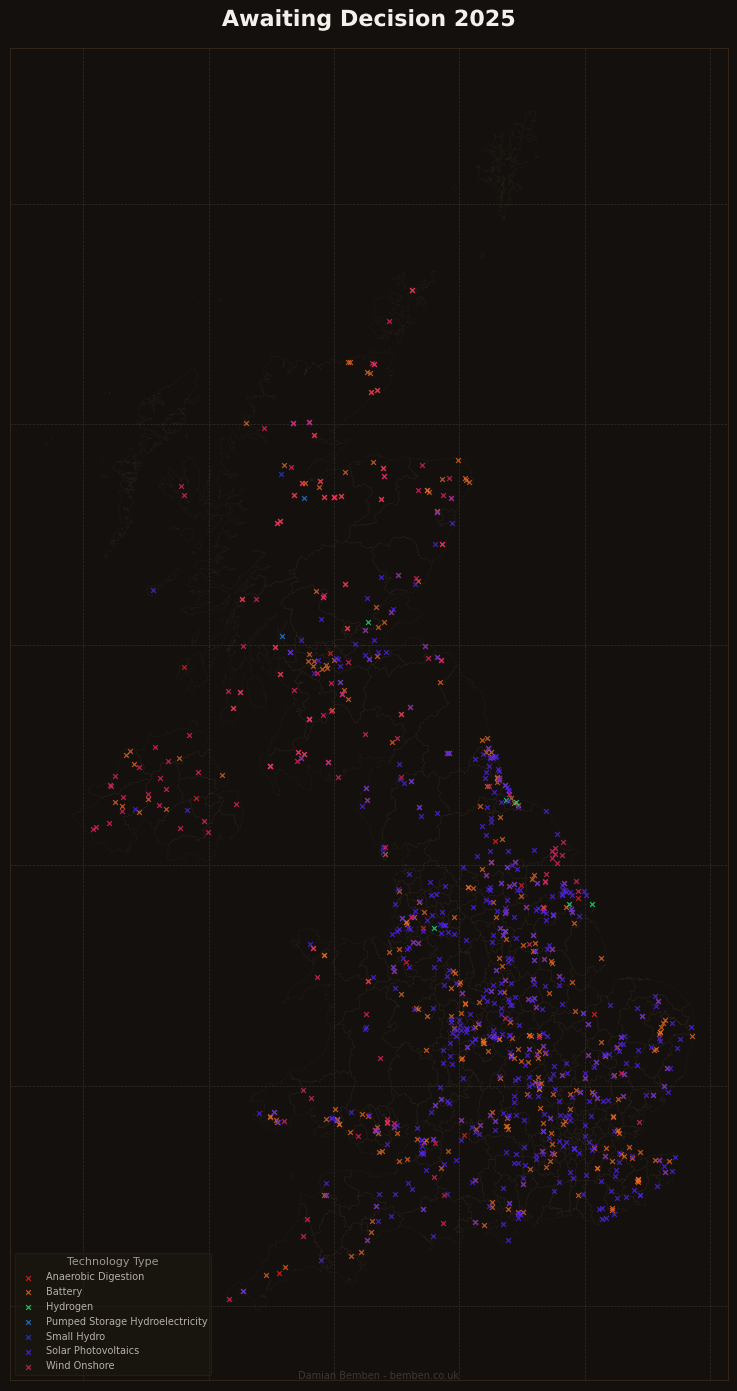

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import numpy as np
import geopandas as gpd

lauth = gpd.read_file("src/data/localauth.json")

all_tech_types = sorted(df["Technology Type"].dropna().unique())
n      = len(all_tech_types)
colors = {tech: mcolors.hsv_to_rgb((i / n, 0.85, 0.92)) for i, tech in enumerate(all_tech_types)}

fig, ax = plt.subplots(figsize=(10, 14), facecolor="#13100d")
ax.set_facecolor("#13100d")

lauth.plot(ax=ax, facecolor="none", edgecolor="#6b5040", linewidth=0.3, alpha=0.2, zorder=1)

for tech, group in df_neutral.groupby("Technology Type"):
    ax.scatter(group.geometry.x, group.geometry.y, c=[colors[tech]],
               marker="x", s=12, linewidths=0.9, alpha=0.75, label=tech, zorder=3)

ax.grid(color="#ffffff", alpha=0.12, linewidth=0.5, linestyle="--")
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor("#332418")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_title("Awaiting Decision 2025", fontsize=16, fontweight="bold",
             color="#f5f0eb", pad=16, path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")])
legend = ax.legend(title="Technology Type", loc="lower left", fontsize=7, title_fontsize=8,
                   framealpha=0.5, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")
legend.get_title().set_color("#a09890")
fig.text(0.59, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


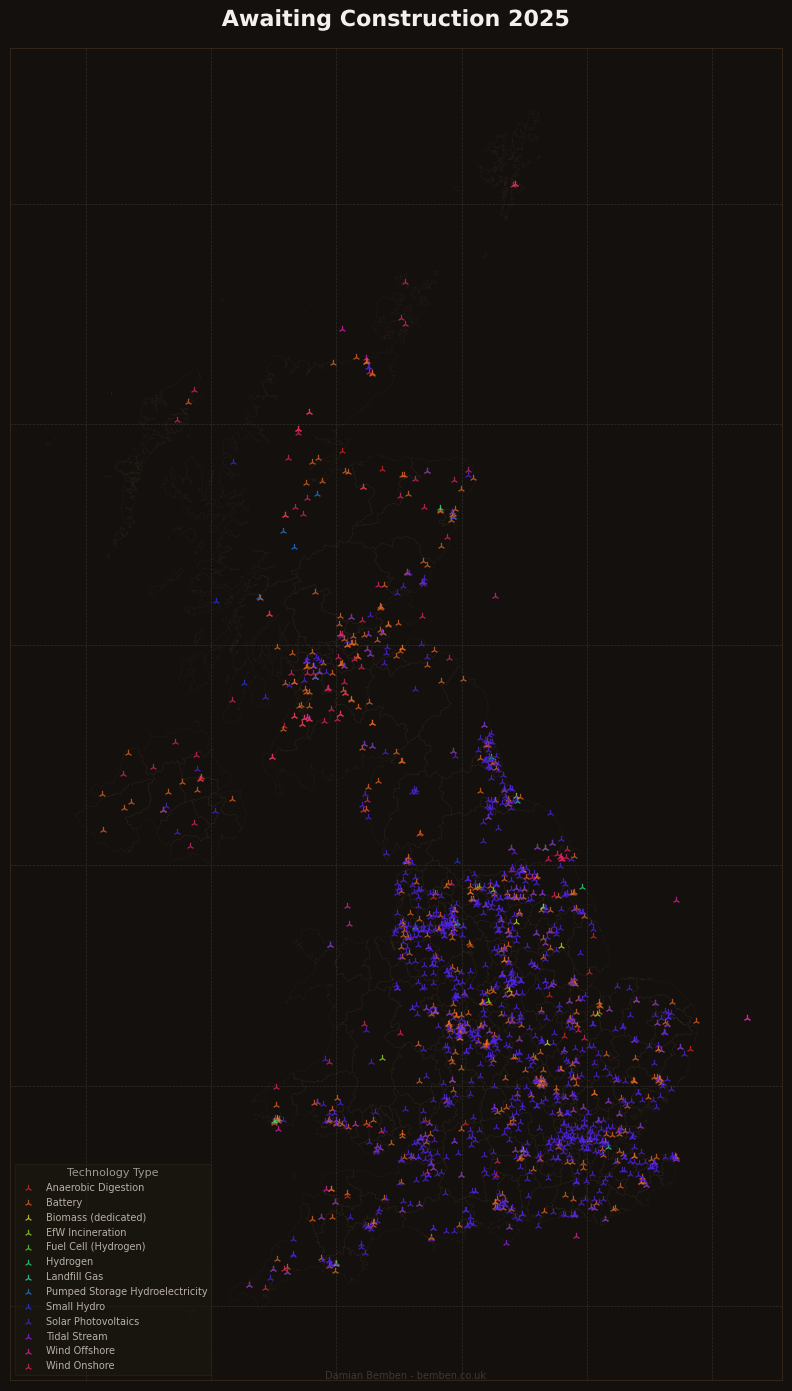

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import geopandas as gpd

lauth = gpd.read_file("src/data/localauth.json")

fig, ax = plt.subplots(figsize=(10, 14), facecolor="#13100d")
ax.set_facecolor("#13100d")

lauth.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#6b5040",
    linewidth=0.3,
    alpha=0.2,
    zorder=1,
)

all_tech_types = sorted(df["Technology Type"].dropna().unique())
n      = len(all_tech_types)
colors = {tech: mcolors.hsv_to_rgb((i / n, 0.85, 0.92)) for i, tech in enumerate(all_tech_types)}


for tech, group in df_awaiting.groupby("Technology Type"):
    ax.scatter(
        group.geometry.x,
        group.geometry.y,
        c=[colors[tech]],
        marker="2",
        s=28,
        linewidths=0.9,
        alpha=0.75,
        label=tech,
        zorder=3,
    )

ax.grid(color="#ffffff", alpha=0.12, linewidth=0.5, linestyle="--")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_edgecolor("#332418")

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

ax.set_title(
    "Awaiting Construction 2025",
    fontsize=16,
    fontweight="bold",
    color="#f5f0eb",
    pad=16,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

legend = ax.legend(
    title="Technology Type",
    loc="lower left",
    fontsize=7,
    title_fontsize=8,
    framealpha=0.5,
    facecolor="#1d1810",
    edgecolor="#332418",
    labelcolor="#b8b0a6",
)
legend.get_title().set_color("#a09890")
fig.text(0.59, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)

plt.tight_layout()
plt.show()


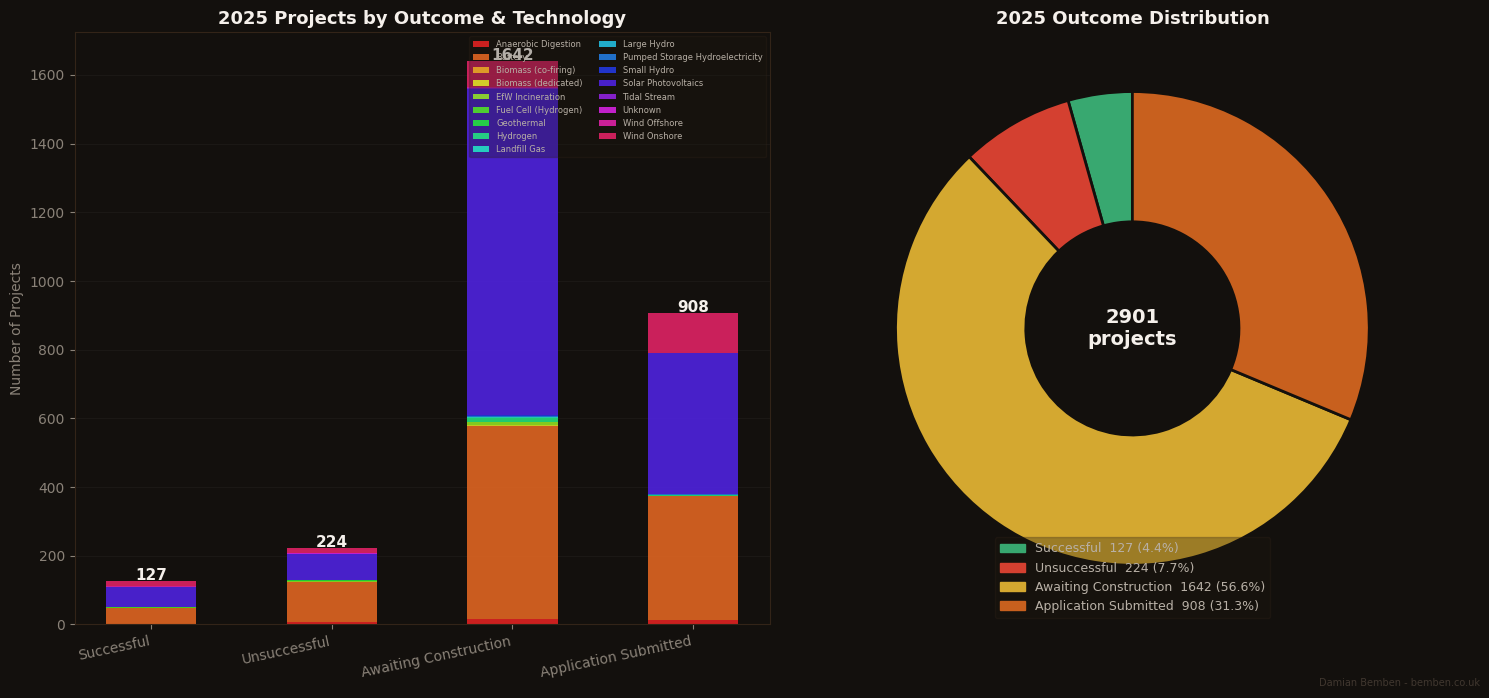

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from src.processors.repd_processor import SUCCESSFUL_DEVELOPMENT_TYPES, UNSUCCESSFUL_DEVELOPMENT_TYPES

df_2025 = df[df["Record Last Updated (dd/mm/yyyy)"].dt.year == 2025]

df_2025_success  = df_2025[df_2025["Development Status (short)"].isin(SUCCESSFUL_DEVELOPMENT_TYPES)]
df_2025_fail     = df_2025[df_2025["Development Status (short)"].isin(UNSUCCESSFUL_DEVELOPMENT_TYPES)]
df_2025_awaiting = df_2025[df_2025["Development Status (short)"] == "Awaiting Construction"]
df_2025_applied  = df_2025[df_2025["Development Status (short)"] == "Application Submitted"]

counts  = {
    "Successful":            len(df_2025_success),
    "Unsuccessful":          len(df_2025_fail),
    "Awaiting Construction": len(df_2025_awaiting),
    "Application Submitted": len(df_2025_applied),
}
total   = sum(counts.values())
palette = {
    "Successful":            "#38a870",
    "Unsuccessful":          "#d44030",
    "Awaiting Construction": "#d4a830",
    "Application Submitted": "#c8601e",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 7), facecolor="#13100d")

# ── Left: stacked bar by technology ──────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#13100d")

dfs_ordered = [df_2025_success, df_2025_fail, df_2025_awaiting, df_2025_applied]
all_techs   = sorted(df["Technology Type"].dropna().unique())
x           = np.arange(4)
bottom      = np.zeros(4)
n_t         = len(all_techs)
tech_colors = {tech: mcolors.hsv_to_rgb((i / n_t, 0.85, 0.92)) for i, tech in enumerate(all_techs)}

for i, tech in enumerate(all_techs):
    vals = [len(d[d["Technology Type"] == tech]) for d in dfs_ordered]
    ax1.bar(x, vals, 0.5, bottom=bottom, color=tech_colors[tech], label=tech, alpha=0.85)
    bottom += np.array(vals)

ax1.set_xticks(x)
ax1.set_xticklabels(list(counts.keys()), color="#b8b0a6", fontsize=10, rotation=12, ha="right")
ax1.set_ylabel("Number of Projects", color="#8a8278", fontsize=10)
ax1.set_title("2025 Projects by Outcome & Technology", color="#f5f0eb", fontsize=13, fontweight="bold")
ax1.tick_params(colors="#8a8278")
for spine in ax1.spines.values():
    spine.set_edgecolor("#332418")
ax1.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)
ax1.set_axisbelow(True)
ax1.legend(fontsize=6, loc="upper right", ncol=2, framealpha=0.3,
           facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

for xi, cnt in enumerate(counts.values()):
    ax1.text(xi, bottom[xi] + 3, str(cnt), ha="center", color="#f5f0eb", fontsize=11, fontweight="bold")

# ── Right: donut chart ────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#13100d")

wedge_colors = [palette[k] for k in counts]
ax2.pie(
    list(counts.values()),
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="#13100d", linewidth=2),
)
ax2.text(0, 0, f"{total}\nprojects", ha="center", va="center",
         fontsize=14, color="#f5f0eb", fontweight="bold")

legend_handles = [
    mpatches.Patch(color=wedge_colors[i], label=f"{k}  {v} ({v/total*100:.1f}%)")
    for i, (k, v) in enumerate(counts.items())
]
ax2.legend(handles=legend_handles, loc="lower center", fontsize=9,
           framealpha=0.3, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")
ax2.set_title("2025 Outcome Distribution", color="#f5f0eb", fontsize=13, fontweight="bold")

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


Planning → Construction:  n=22  mean=2.1 yrs  median=1.6 yrs
Construction → Operational:  n=16  mean=1.6 yrs  median=1.0 yrs


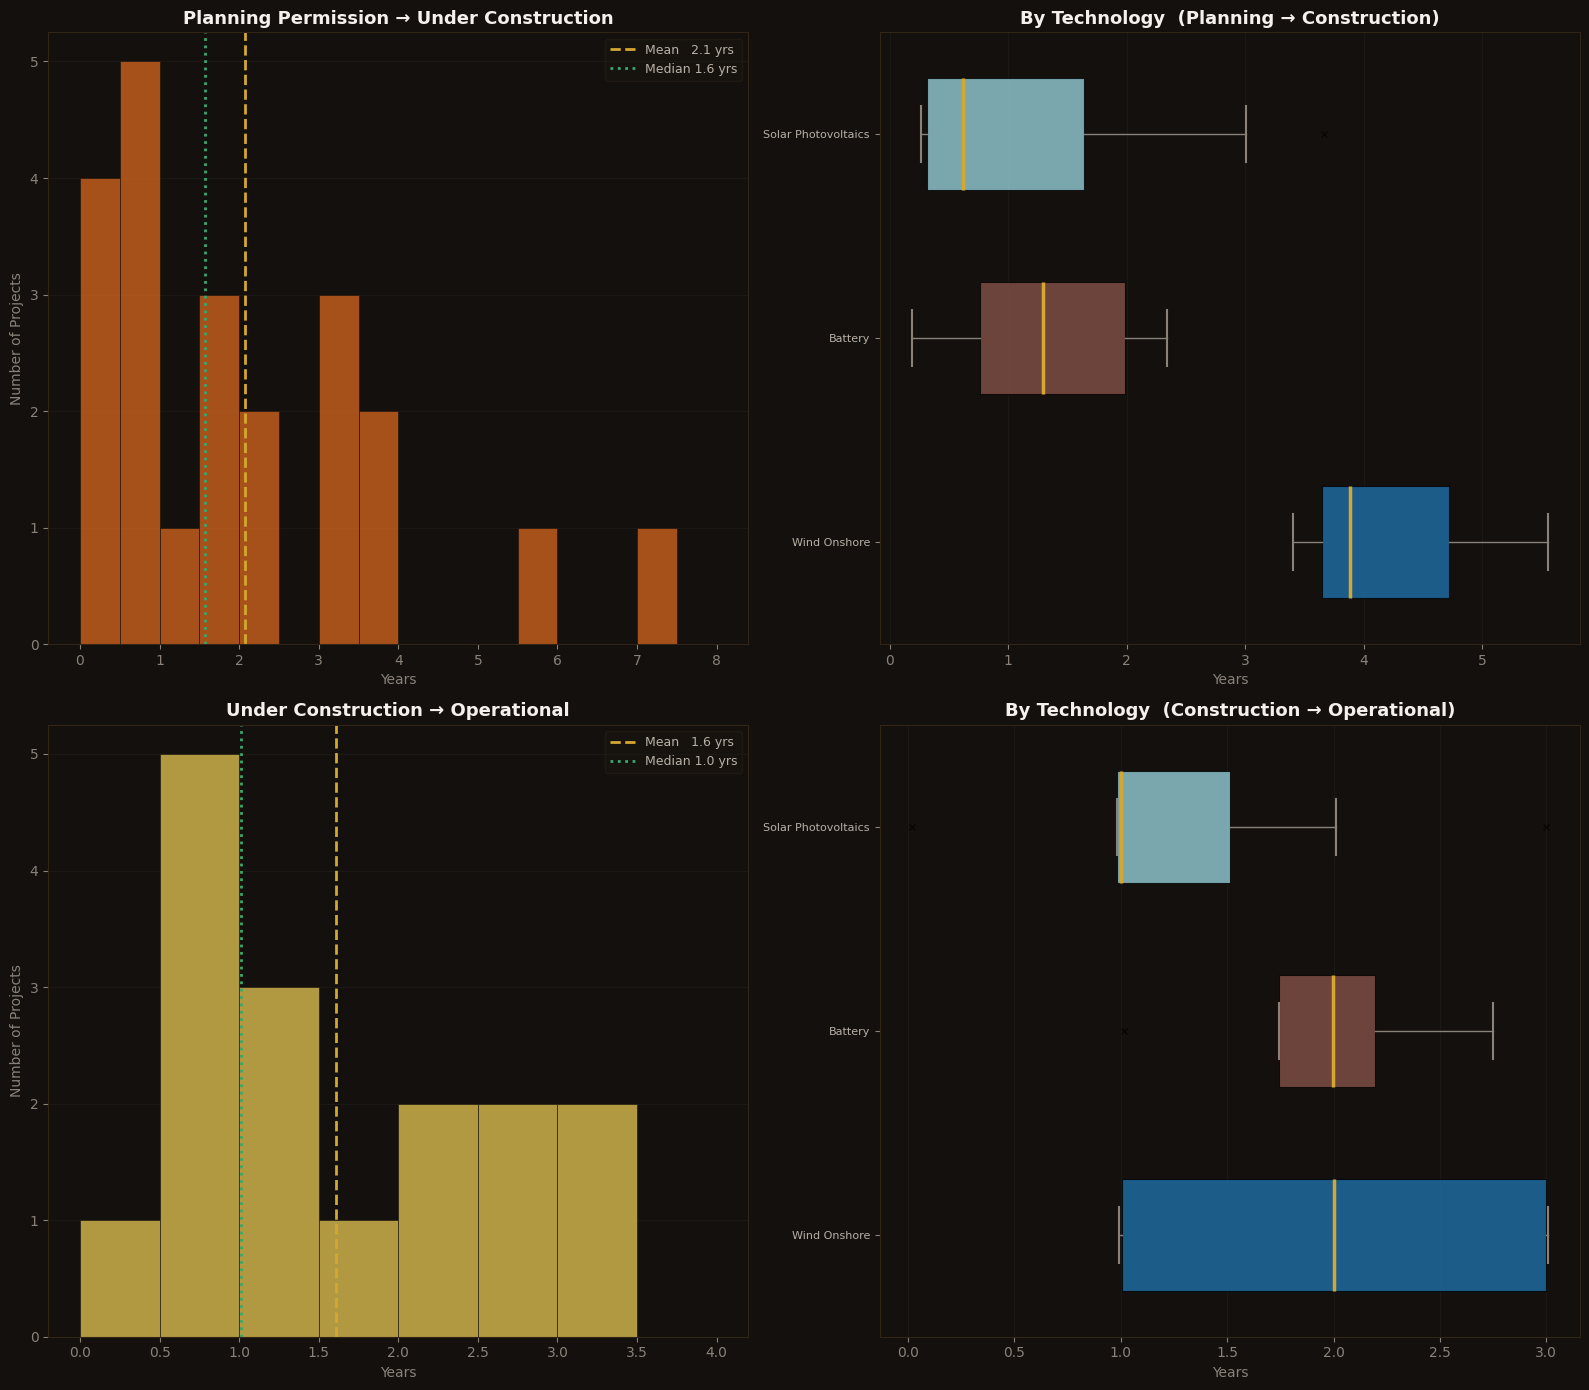

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── Planning Permission Granted → Under Construction ──────────────────────────
df_uc = df[
    (df["Development Status (short)"] == "Under Construction")
    & df["Planning Permission Granted"].notna()
    & df["Under Construction"].notna()
].copy()
df_uc["delay_days"]  = (df_uc["Under Construction"] - df_uc["Planning Permission Granted"]).dt.days
df_uc                = df_uc[df_uc["delay_days"] >= 0]
df_uc["delay_years"] = df_uc["delay_days"] / 365.25

# ── Under Construction → Operational ─────────────────────────────────────────
df_op = df[
    df["Under Construction"].notna()
    & df["Operational"].notna()
].copy()
df_op["delay_days"]  = (df_op["Operational"] - df_op["Under Construction"]).dt.days
df_op                = df_op[df_op["delay_days"] >= 0]
df_op["delay_years"] = df_op["delay_days"] / 365.25

for label, d in [("Planning → Construction", df_uc), ("Construction → Operational", df_op)]:
    print(f"{label}:  n={len(d)}  mean={d['delay_years'].mean():.1f} yrs  median={d['delay_years'].median():.1f} yrs")

fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor="#13100d")

def style_ax(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)

def hist_panel(ax, data, mean_y, median_y, title, color):
    style_ax(ax)
    bins = np.arange(0, data["delay_years"].max() + 1, 0.5)
    ax.hist(data["delay_years"], bins=bins, color=color, alpha=0.82,
            edgecolor="#13100d", linewidth=0.5)
    ax.axvline(mean_y,   color="#d4a830", linewidth=2, linestyle="--", label=f"Mean   {mean_y:.1f} yrs")
    ax.axvline(median_y, color="#38a870", linewidth=2, linestyle=":",  label=f"Median {median_y:.1f} yrs")
    ax.set_title(title, color="#f5f0eb", fontsize=13, fontweight="bold")
    ax.set_xlabel("Years", color="#8a8278", fontsize=10)
    ax.set_ylabel("Number of Projects", color="#8a8278", fontsize=10)
    ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)
    ax.legend(fontsize=9, framealpha=0.4, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

def box_panel(ax, data, title):
    style_ax(ax)
    tech_order = (
        data.groupby("Technology Type")["delay_years"]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    tech_order  = [t for t in tech_order if len(data[data["Technology Type"] == t]) >= 3]
    data_groups = [data[data["Technology Type"] == t]["delay_years"].values for t in tech_order]
    tech_cmap   = plt.get_cmap("tab20", len(tech_order))

    bp = ax.boxplot(
        data_groups,
        vert=False,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="#d4a830", linewidth=2.5),
        whiskerprops=dict(color="#8a8278", linewidth=1),
        capprops=dict(color="#8a8278", linewidth=1.5),
        flierprops=dict(marker="x", color="#d44030", markersize=4, alpha=0.6),
        boxprops=dict(linewidth=0.8),
    )
    for patch, idx in zip(bp["boxes"], range(len(tech_order))):
        patch.set_facecolor(tech_cmap(idx))
        patch.set_alpha(0.75)

    ax.set_yticks(range(1, len(tech_order) + 1))
    ax.set_yticklabels(tech_order, color="#b8b0a6", fontsize=8)
    ax.set_xlabel("Years", color="#8a8278", fontsize=10)
    ax.set_title(title, color="#f5f0eb", fontsize=13, fontweight="bold")
    ax.grid(axis="x", color="#ffffff", alpha=0.05, linewidth=0.5)

# Row 0: Planning → Construction
hist_panel(axes[0, 0], df_uc, df_uc["delay_years"].mean(), df_uc["delay_years"].median(),
           "Planning Permission → Under Construction", "#c8601e")
box_panel(axes[0, 1], df_uc, "By Technology  (Planning → Construction)")

# Row 1: Construction → Operational
hist_panel(axes[1, 0], df_op, df_op["delay_years"].mean(), df_op["delay_years"].median(),
           "Under Construction → Operational", "#d4b84c")
box_panel(axes[1, 1], df_op, "By Technology  (Construction → Operational)")

plt.tight_layout()
plt.show()


Planning → Operational (2025):  n=11  mean=3.1 yrs  median=2.7 yrs


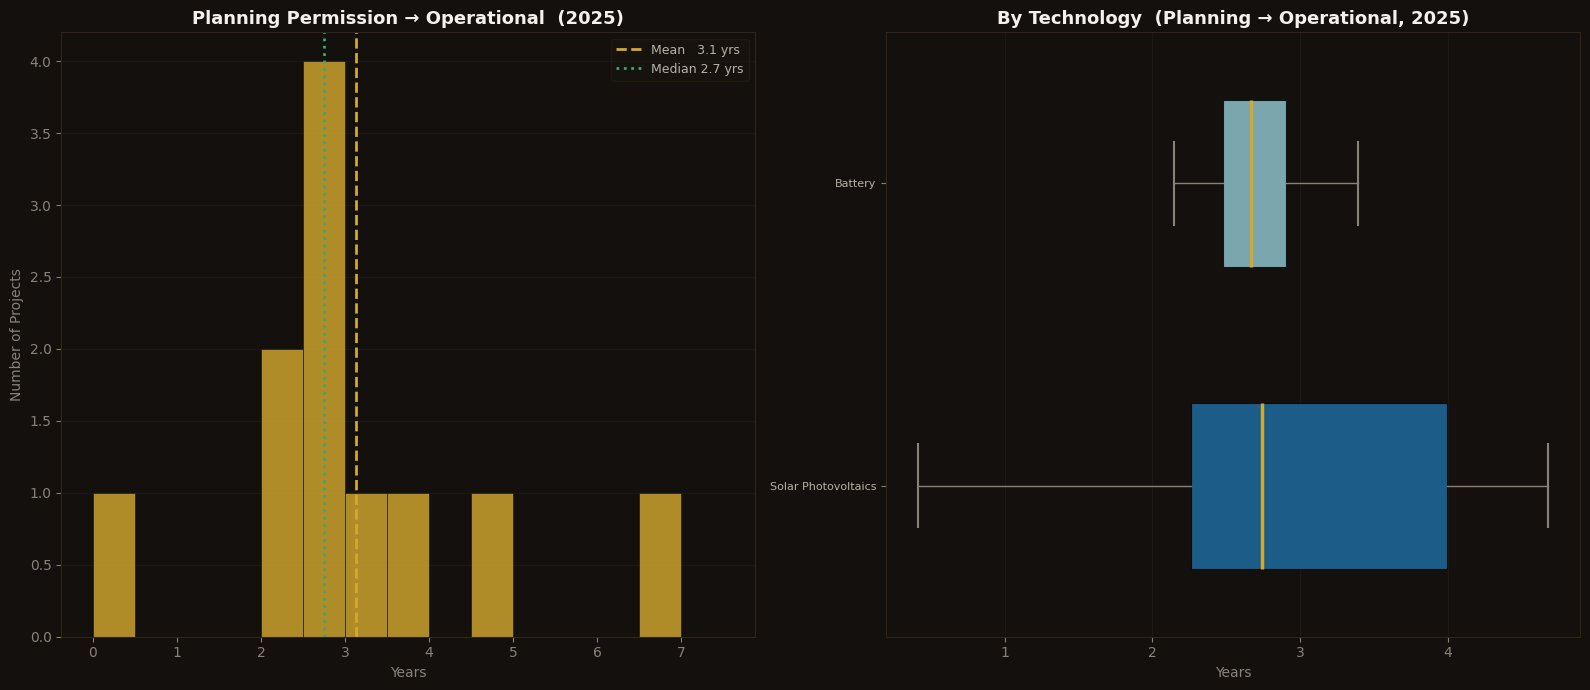

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Planning Permission Granted → Operational, records updated in 2025
df_full = df[
    df["Record Last Updated (dd/mm/yyyy)"].dt.year == 2025
].copy()
df_full = df_full[
    df_full["Planning Permission Granted"].notna()
    & df_full["Operational"].notna()
].copy()
df_full["delay_days"]  = (df_full["Operational"] - df_full["Planning Permission Granted"]).dt.days
df_full                = df_full[df_full["delay_days"] >= 0]
df_full["delay_years"] = df_full["delay_days"] / 365.25

mean_y   = df_full["delay_years"].mean()
median_y = df_full["delay_years"].median()
print(f"Planning → Operational (2025):  n={len(df_full)}  mean={mean_y:.1f} yrs  median={median_y:.1f} yrs")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#13100d")

def style_ax(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)

# ── Left: histogram ───────────────────────────────────────────────────────────
ax1 = axes[0]
style_ax(ax1)
bins = np.arange(0, df_full["delay_years"].max() + 1, 0.5)
ax1.hist(df_full["delay_years"], bins=bins, color="#d4a830", alpha=0.82,
         edgecolor="#13100d", linewidth=0.5)
ax1.axvline(mean_y,   color="#d4a830", linewidth=2, linestyle="--", label=f"Mean   {mean_y:.1f} yrs")
ax1.axvline(median_y, color="#38a870", linewidth=2, linestyle=":",  label=f"Median {median_y:.1f} yrs")
ax1.set_title("Planning Permission → Operational  (2025)", color="#f5f0eb", fontsize=13, fontweight="bold")
ax1.set_xlabel("Years", color="#8a8278", fontsize=10)
ax1.set_ylabel("Number of Projects", color="#8a8278", fontsize=10)
ax1.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)
ax1.legend(fontsize=9, framealpha=0.4, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

# ── Right: box plot by technology ─────────────────────────────────────────────
ax2 = axes[1]
style_ax(ax2)
tech_order = (
    df_full.groupby("Technology Type")["delay_years"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
tech_order  = [t for t in tech_order if len(df_full[df_full["Technology Type"] == t]) >= 3]
data_groups = [df_full[df_full["Technology Type"] == t]["delay_years"].values for t in tech_order]
tech_cmap   = plt.get_cmap("tab20", len(tech_order))

bp = ax2.boxplot(
    data_groups,
    vert=False,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color="#d4a830", linewidth=2.5),
    whiskerprops=dict(color="#8a8278", linewidth=1),
    capprops=dict(color="#8a8278", linewidth=1.5),
    flierprops=dict(marker="x", color="#d44030", markersize=4, alpha=0.6),
    boxprops=dict(linewidth=0.8),
)
for patch, idx in zip(bp["boxes"], range(len(tech_order))):
    patch.set_facecolor(tech_cmap(idx))
    patch.set_alpha(0.75)

ax2.set_yticks(range(1, len(tech_order) + 1))
ax2.set_yticklabels(tech_order, color="#b8b0a6", fontsize=8)
ax2.set_xlabel("Years", color="#8a8278", fontsize=10)
ax2.set_title("By Technology  (Planning → Operational, 2025)", color="#f5f0eb", fontsize=13, fontweight="bold")
ax2.grid(axis="x", color="#ffffff", alpha=0.05, linewidth=0.5)

plt.tight_layout()
plt.show()


[Choropleth] Operational — unmatched authorities: 2, records dropped: 8
[Choropleth] Stuck       — unmatched authorities: 16, records dropped: 287


/var/folders/pg/5vwf2pn945b9rjc9srsm91tc0000gn/T/ipykernel_10099/1136227356.py:71: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top["centroid"] = top.geometry.centroid
/var/folders/pg/5vwf2pn945b9rjc9srsm91tc0000gn/T/ipykernel_10099/1136227356.py:71: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top["centroid"] = top.geometry.centroid


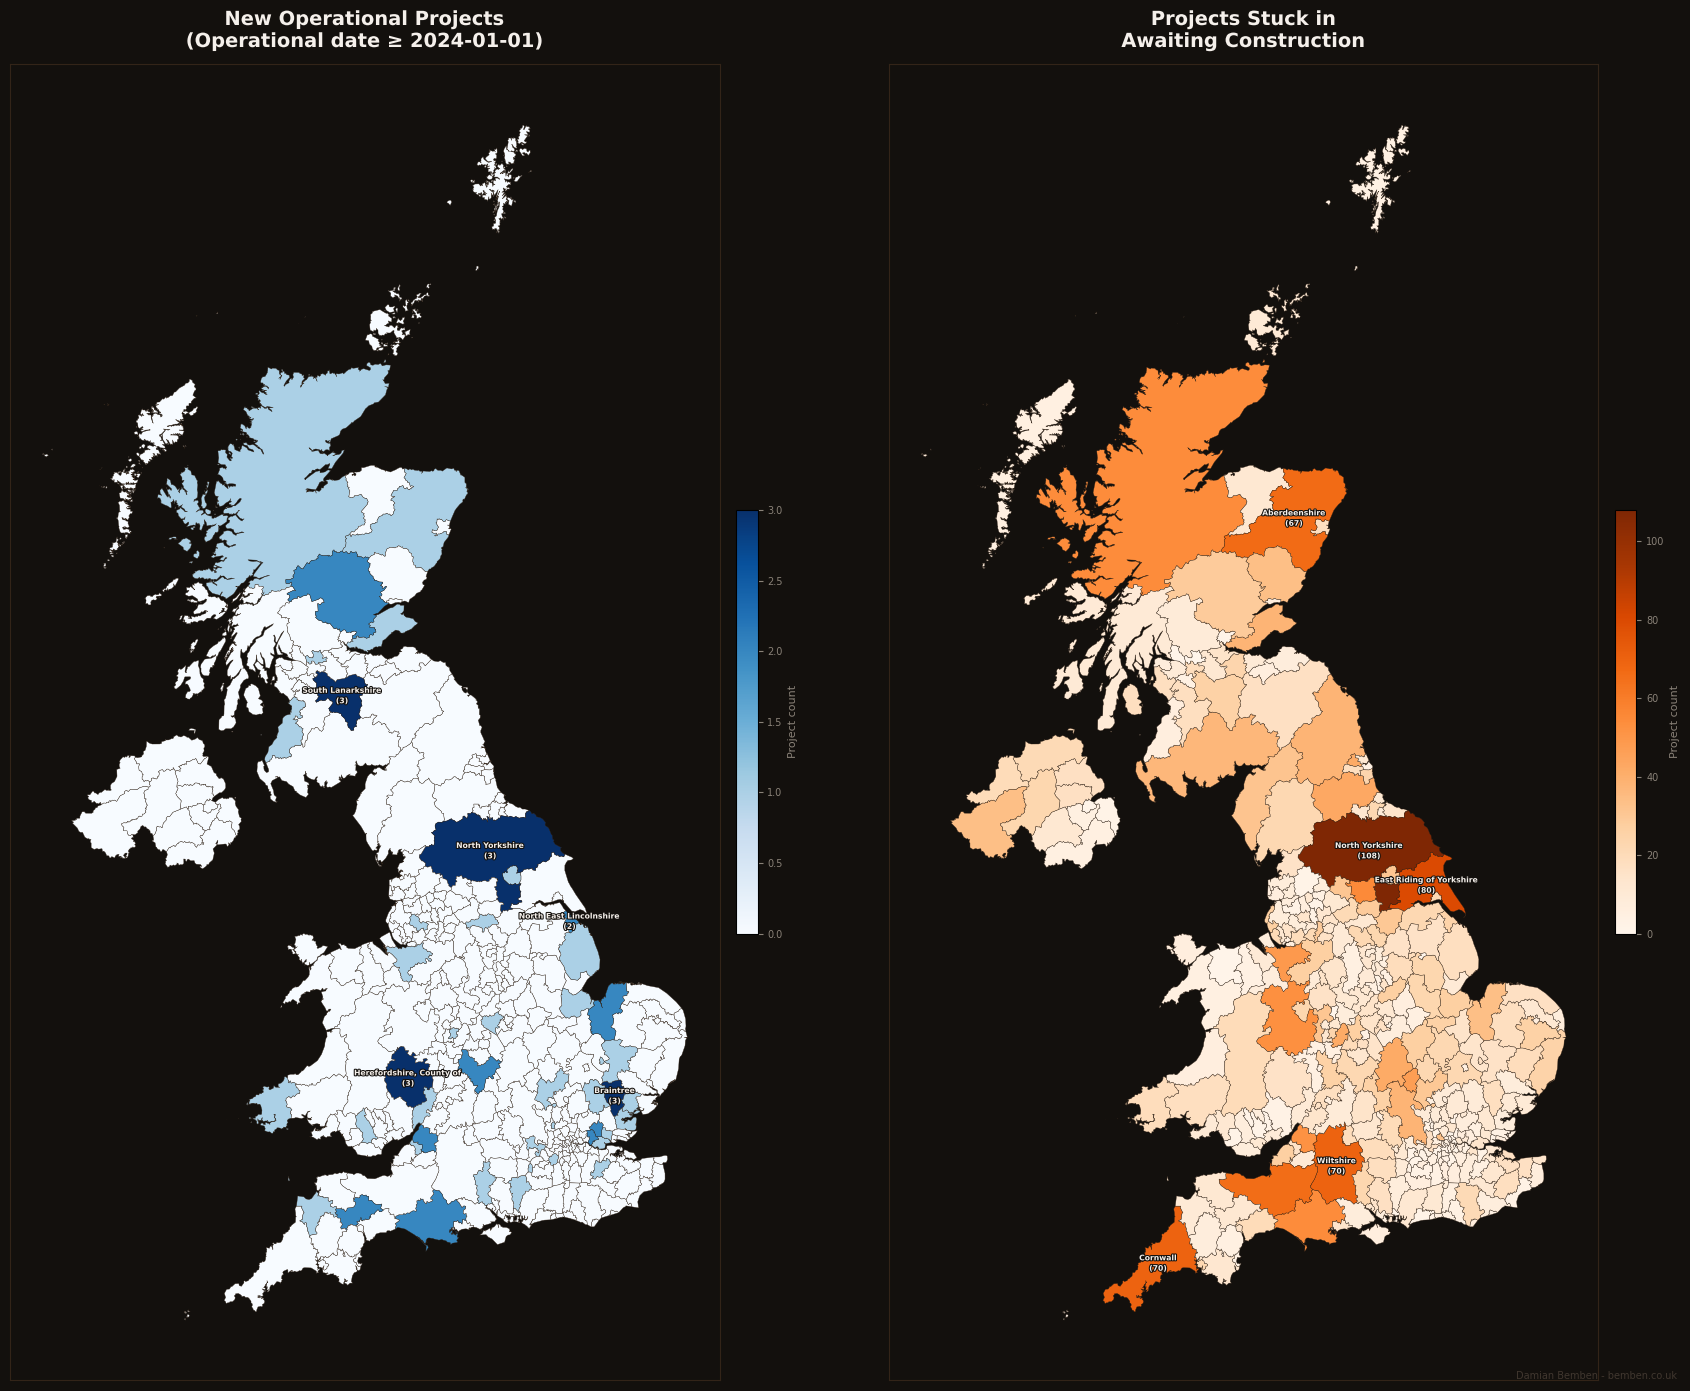

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import geopandas as gpd
import pandas as pd
import numpy as np

# ── Load full REPD (no date filter) for maximum geographic coverage ────────────
repd_full = pd.read_csv("src/data/REPD_Publication_Q4_2025.csv", encoding="utf-8")
repd_full["Operational"] = pd.to_datetime(repd_full["Operational"], dayfirst=True, errors="coerce")
repd_full["Planning Permission Granted"] = pd.to_datetime(
    repd_full["Planning Permission Granted"], dayfirst=True, errors="coerce"
)
repd_full["Installed Capacity (MWelec)"] = pd.to_numeric(
    repd_full["Installed Capacity (MWelec)"], errors="coerce"
)

# ── Authority name normalisation ──────────────────────────────────────────────
repd_full["auth_joined"] = repd_full["Planning Authority"].str.strip()
_AUTHORITY_ALIASES = {
    "Durham":               "County Durham",
    "Hyndburn Borough":     "Hyndburn",
    "Burnely":              "Burnley",
    "Knowsley Borough":     "Knowsley",
    "Birmingham Ladywood":  "Birmingham",
}
repd_full["auth_joined"] = repd_full["auth_joined"].replace(_AUTHORITY_ALIASES)

# ── Load local authority boundaries ──────────────────────────────────────────
lauth = gpd.read_file("src/data/localauth.json")

# ── Operational count: Operational date >= 2024-01-01 ─────────────────────────
op_mask = (
    (repd_full["Development Status (short)"] == "Operational")
    & (repd_full["Operational"] >= "2024-01-01")
)
op_counts = (
    repd_full[op_mask]
    .groupby("auth_joined")
    .size()
    .reset_index(name="op_count")
)

# ── Stuck count: Awaiting Construction ───────────────────────────────────────
stuck_mask = repd_full["Development Status (short)"] == "Awaiting Construction"
stuck_counts = (
    repd_full[stuck_mask]
    .groupby("auth_joined")
    .size()
    .reset_index(name="stuck_count")
)

# ── Join to GeoJSON ───────────────────────────────────────────────────────────
geo_op    = lauth.merge(op_counts,    left_on="LAD24NM", right_on="auth_joined", how="left")
geo_stuck = lauth.merge(stuck_counts, left_on="LAD24NM", right_on="auth_joined", how="left")
geo_op["op_count"]       = geo_op["op_count"].fillna(0).astype(int)
geo_stuck["stuck_count"] = geo_stuck["stuck_count"].fillna(0).astype(int)

# ── Diagnostic: unmatched non-geographic bodies ───────────────────────────────
geo_auth_set    = set(lauth["LAD24NM"])
op_unmatched    = set(repd_full.loc[op_mask,    "auth_joined"].dropna()) - geo_auth_set
stuck_unmatched = set(repd_full.loc[stuck_mask, "auth_joined"].dropna()) - geo_auth_set
print(f"[Choropleth] Operational — unmatched authorities: {len(op_unmatched)}, "
      f"records dropped: {repd_full[op_mask & repd_full['auth_joined'].isin(op_unmatched)].shape[0]}")
print(f"[Choropleth] Stuck       — unmatched authorities: {len(stuck_unmatched)}, "
      f"records dropped: {repd_full[stuck_mask & repd_full['auth_joined'].isin(stuck_unmatched)].shape[0]}")

# ── Top-N annotation helper ───────────────────────────────────────────────────
def _annotate_top(gdf, col, ax, n=5):
    top = gdf.nlargest(n, col).copy()
    top["centroid"] = top.geometry.centroid
    for _, row in top.iterrows():
        ax.annotate(
            f"{row['LAD24NM']}\n({int(row[col])})",
            xy=(row["centroid"].x, row["centroid"].y),
            fontsize=5.5, ha="center", va="center",
            color="#f5f0eb", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=1.5, foreground="#13100d")],
        )

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 14), facecolor="#13100d")
_EDGE = dict(edgecolor="#332418", linewidth=0.25)

for ax, gdf, col, cmap, title in [
    (axes[0], geo_op,    "op_count",    "Blues",
     "New Operational Projects\n(Operational date ≥ 2024-01-01)"),
    (axes[1], geo_stuck, "stuck_count", "Oranges",
     "Projects Stuck in\nAwaiting Construction"),
]:
    ax.set_facecolor("#13100d")
    vmax = max(gdf[col].max(), 1)

    gdf.plot(
        column=col, ax=ax, cmap=cmap, vmin=0, vmax=vmax,
        missing_kwds=dict(color="#1d1810", **_EDGE), **_EDGE,
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cb.ax.tick_params(colors="#8a8278", labelsize=7)
    cb.set_label("Project count", color="#8a8278", fontsize=8)

    _annotate_top(gdf, col, ax)
    ax.set_title(title, fontsize=14, fontweight="bold", color="#f5f0eb", pad=12,
                 path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


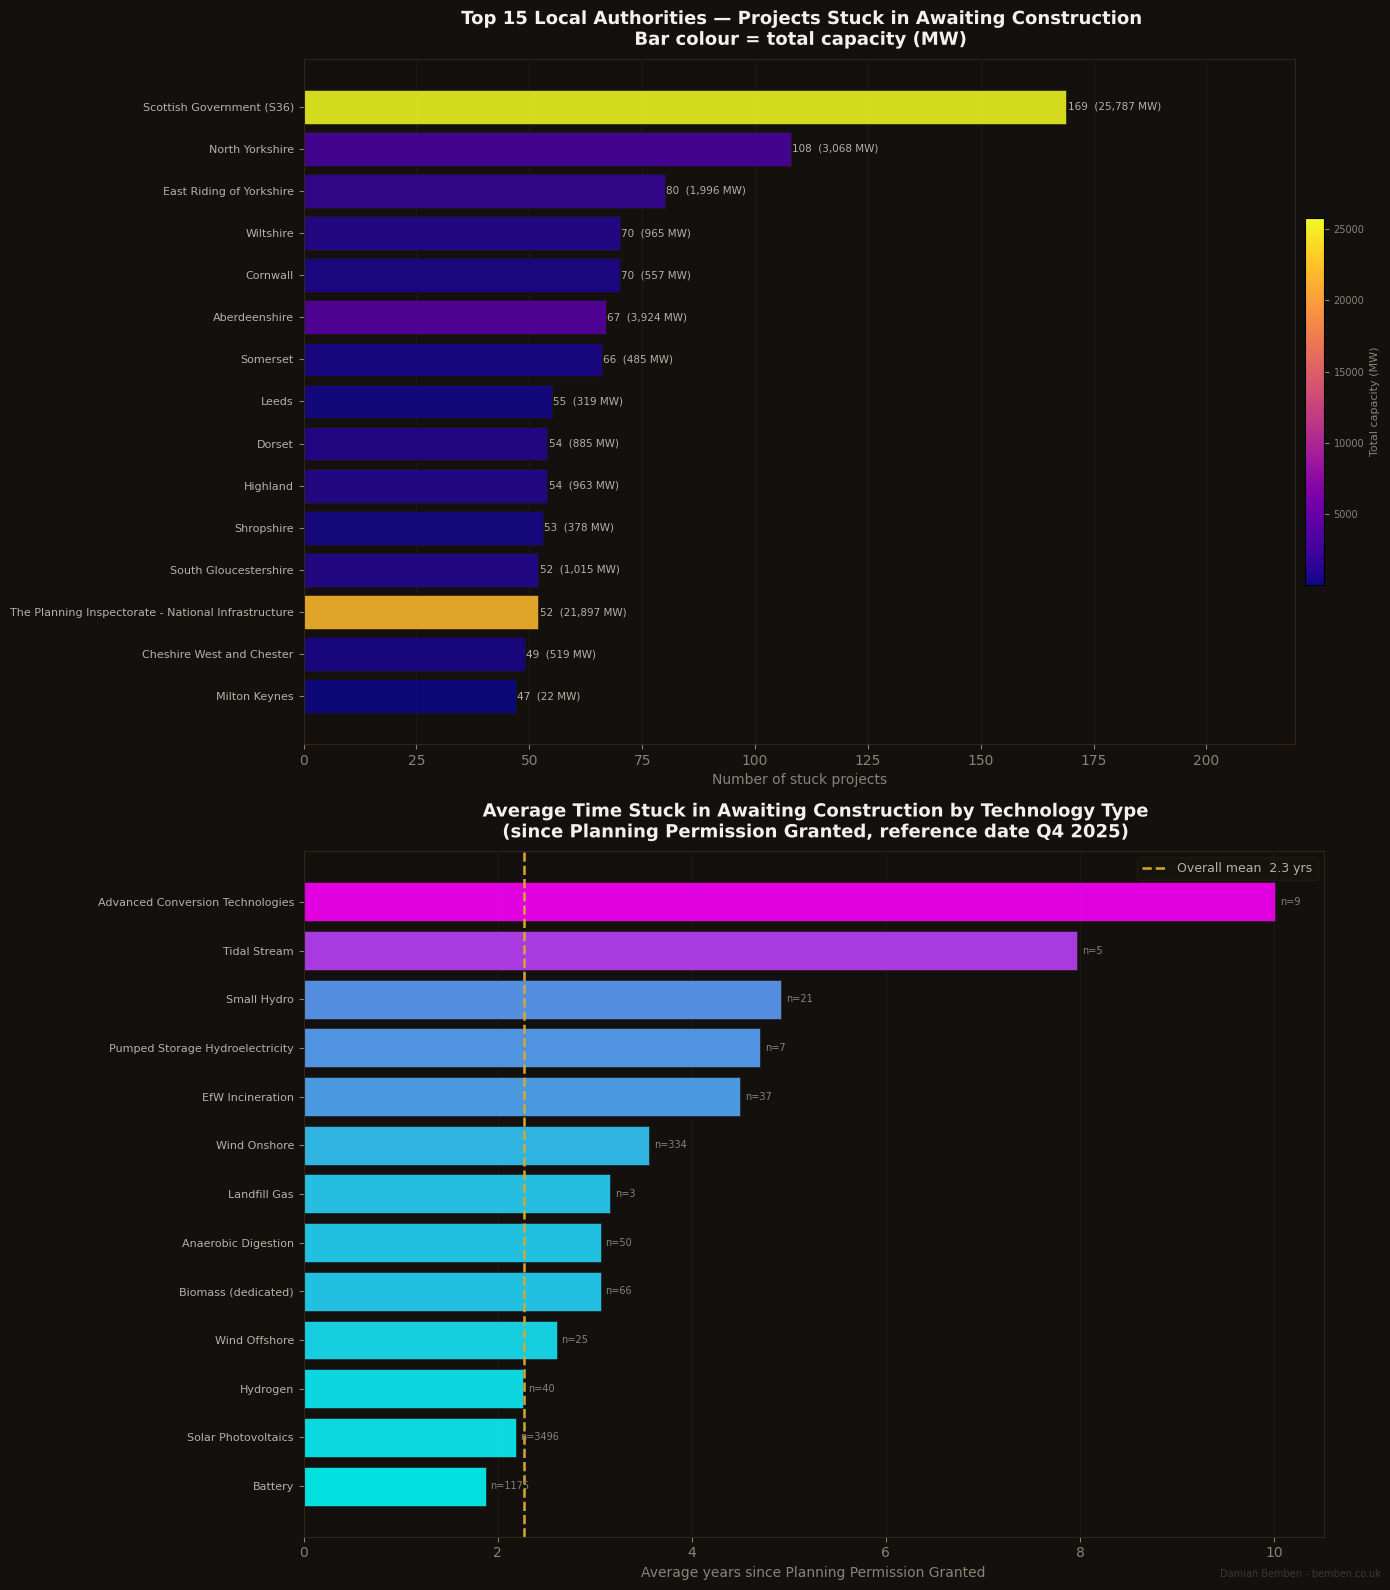

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# ── Top-15 stuck local authorities ────────────────────────────────────────────
stuck_by_auth = (
    repd_full[stuck_mask]
    .groupby("auth_joined")
    .agg(
        project_count=("Ref ID",                     "count"),
        total_mw     =("Installed Capacity (MWelec)", "sum"),
    )
    .sort_values("project_count", ascending=False)
    .head(15)
    .sort_values("project_count", ascending=True)
)

# ── Average years stuck by technology type ────────────────────────────────────
_REF_DATE = pd.Timestamp("2025-12-31")
awaiting_ppg = repd_full[
    stuck_mask & repd_full["Planning Permission Granted"].notna()
].copy()
awaiting_ppg["days_stuck"] = (_REF_DATE - awaiting_ppg["Planning Permission Granted"]).dt.days
awaiting_ppg = awaiting_ppg[awaiting_ppg["days_stuck"] >= 0]

tech_stuck = (
    awaiting_ppg.groupby("Technology Type")["days_stuck"]
    .agg(mean_days="mean", count="count")
    .query("count >= 3")
    .sort_values("mean_days", ascending=True)
)
overall_mean_days = awaiting_ppg["days_stuck"].mean()

# ── Helpers ───────────────────────────────────────────────────────────────────
def _norm_colors(values, cmap_name):
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = plt.get_cmap(cmap_name)
    return [cmap(norm(v)) for v in values]

def _style_ax(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#ffffff", alpha=0.06, linewidth=0.5)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 16), facecolor="#13100d")

# ── Top panel: authorities ────────────────────────────────────────────────────
ax_top = axes[0]
_style_ax(ax_top)

bar_colors = _norm_colors(stuck_by_auth["total_mw"].fillna(0), "plasma")
bars = ax_top.barh(
    stuck_by_auth.index,
    stuck_by_auth["project_count"],
    color=bar_colors, alpha=0.88, edgecolor="#1d1810", linewidth=0.5,
)
for bar, count, mw in zip(bars, stuck_by_auth["project_count"], stuck_by_auth["total_mw"].fillna(0)):
    ax_top.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{count}  ({mw:,.0f} MW)",
        va="center", fontsize=7.5, color="#b8b0a6",
    )

sm_top = plt.cm.ScalarMappable(
    cmap=plt.get_cmap("plasma"),
    norm=mcolors.Normalize(vmin=stuck_by_auth["total_mw"].min(), vmax=stuck_by_auth["total_mw"].max())
)
sm_top.set_array([])
cb_top = fig.colorbar(sm_top, ax=ax_top, fraction=0.018, pad=0.01)
cb_top.set_label("Total capacity (MW)", color="#8a8278", fontsize=8)
cb_top.ax.tick_params(colors="#8a8278", labelsize=7)

ax_top.set_xlim(0, stuck_by_auth["project_count"].max() * 1.3)
ax_top.set_xlabel("Number of stuck projects", color="#8a8278", fontsize=10)
ax_top.tick_params(axis="y", labelcolor="#b8b0a6", labelsize=8)
ax_top.set_title(
    "Top 15 Local Authorities — Projects Stuck in Awaiting Construction\n"
    "Bar colour = total capacity (MW)",
    color="#f5f0eb", fontsize=13, fontweight="bold", pad=10,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

# ── Bottom panel: technology types ───────────────────────────────────────────
ax_bot = axes[1]
_style_ax(ax_bot)

tech_colors = _norm_colors(tech_stuck["mean_days"], "cool")
ax_bot.barh(
    tech_stuck.index,
    tech_stuck["mean_days"] / 365.25,
    color=tech_colors, alpha=0.88, edgecolor="#1d1810", linewidth=0.5,
)
ax_bot.axvline(
    overall_mean_days / 365.25,
    color="#d4a830", linewidth=1.8, linestyle="--",
    label=f"Overall mean  {overall_mean_days / 365.25:.1f} yrs",
)
for i, (tech, row) in enumerate(tech_stuck.iterrows()):
    ax_bot.text(
        row["mean_days"] / 365.25 + 0.05, i,
        f"n={int(row['count'])}",
        va="center", fontsize=7, color="#8a8278",
    )

ax_bot.set_xlabel("Average years since Planning Permission Granted", color="#8a8278", fontsize=10)
ax_bot.tick_params(axis="y", labelcolor="#b8b0a6", labelsize=8)
ax_bot.legend(fontsize=9, framealpha=0.4, facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")
ax_bot.set_title(
    "Average Time Stuck in Awaiting Construction by Technology Type\n"
    "(since Planning Permission Granted, reference date Q4 2025)",
    color="#f5f0eb", fontsize=13, fontweight="bold", pad=10,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


## Bubble Chart: Delay vs. Project Volume by Local Authority

Each bubble is a **local authority**. Position shows the relationship between average planning delay (X) and total project count (Y) for that LA within each status group.
Bubble size ∝ total installed capacity (MWelec). Top outlier LAs are labelled.

In [ ]:

_TODAY = pd.Timestamp.now()

def _agg_by_la(src_df, min_count=2):
    src_df = src_df.copy()
    src_df['cap'] = pd.to_numeric(src_df['Installed Capacity (MWelec)'], errors='coerce').fillna(0)
    return (
        src_df
        .groupby('Planning Authority')
        .agg(count=('Ref ID', 'count'), avg_delay=('delay_yrs', 'mean'), total_cap=('cap', 'sum'))
        .query(f'count >= {min_count}')
        .reset_index()
    )

# Under Construction: permission granted → construction start
_df_uc = df[df['Development Status (short)'] == 'Under Construction'].copy()
_df_uc['delay_yrs'] = (_df_uc['Under Construction'] - _df_uc['Planning Permission Granted']).dt.days / 365.25
la_uc = _agg_by_la(_df_uc[_df_uc['delay_yrs'] > 0])

# Operational: construction start → operational
_df_op = df[df['Development Status (short)'] == 'Operational'].copy()
_df_op['delay_yrs'] = (_df_op['Operational'] - _df_op['Under Construction']).dt.days / 365.25
la_op = _agg_by_la(_df_op[_df_op['delay_yrs'] > 0])

# Awaiting Construction: permission granted → today
_df_aw = df[df['Development Status (short)'] == 'Awaiting Construction'].copy()
_df_aw['delay_yrs'] = (_TODAY - _df_aw['Planning Permission Granted']).dt.days / 365.25
la_aw = _agg_by_la(_df_aw[_df_aw['delay_yrs'] > 0])

# Denied: application submitted → refusal (fallback: record last updated)
_df_dn = df[df['Development Status (short)'].isin(UNSUCCESSFUL_DEVELOPMENT_TYPES)].copy()
_df_dn['end_date'] = _df_dn['Planning Permission Refused'].fillna(_df_dn['Record Last Updated (dd/mm/yyyy)'])
_df_dn['delay_yrs'] = (_df_dn['end_date'] - _df_dn['Planning Application Submitted']).dt.days / 365.25
la_dn = _agg_by_la(_df_dn[_df_dn['delay_yrs'] > 0])

for _name, _agg in [('Under Construction', la_uc), ('Operational', la_op),
                    ('Awaiting Construction', la_aw), ('Denied', la_dn)]:
    print(f'{_name}: {len(_agg)} local authorities')


Under Construction: 4 local authorities
Operational: 3 local authorities
Awaiting Construction: 134 local authorities
Denied: 47 local authorities


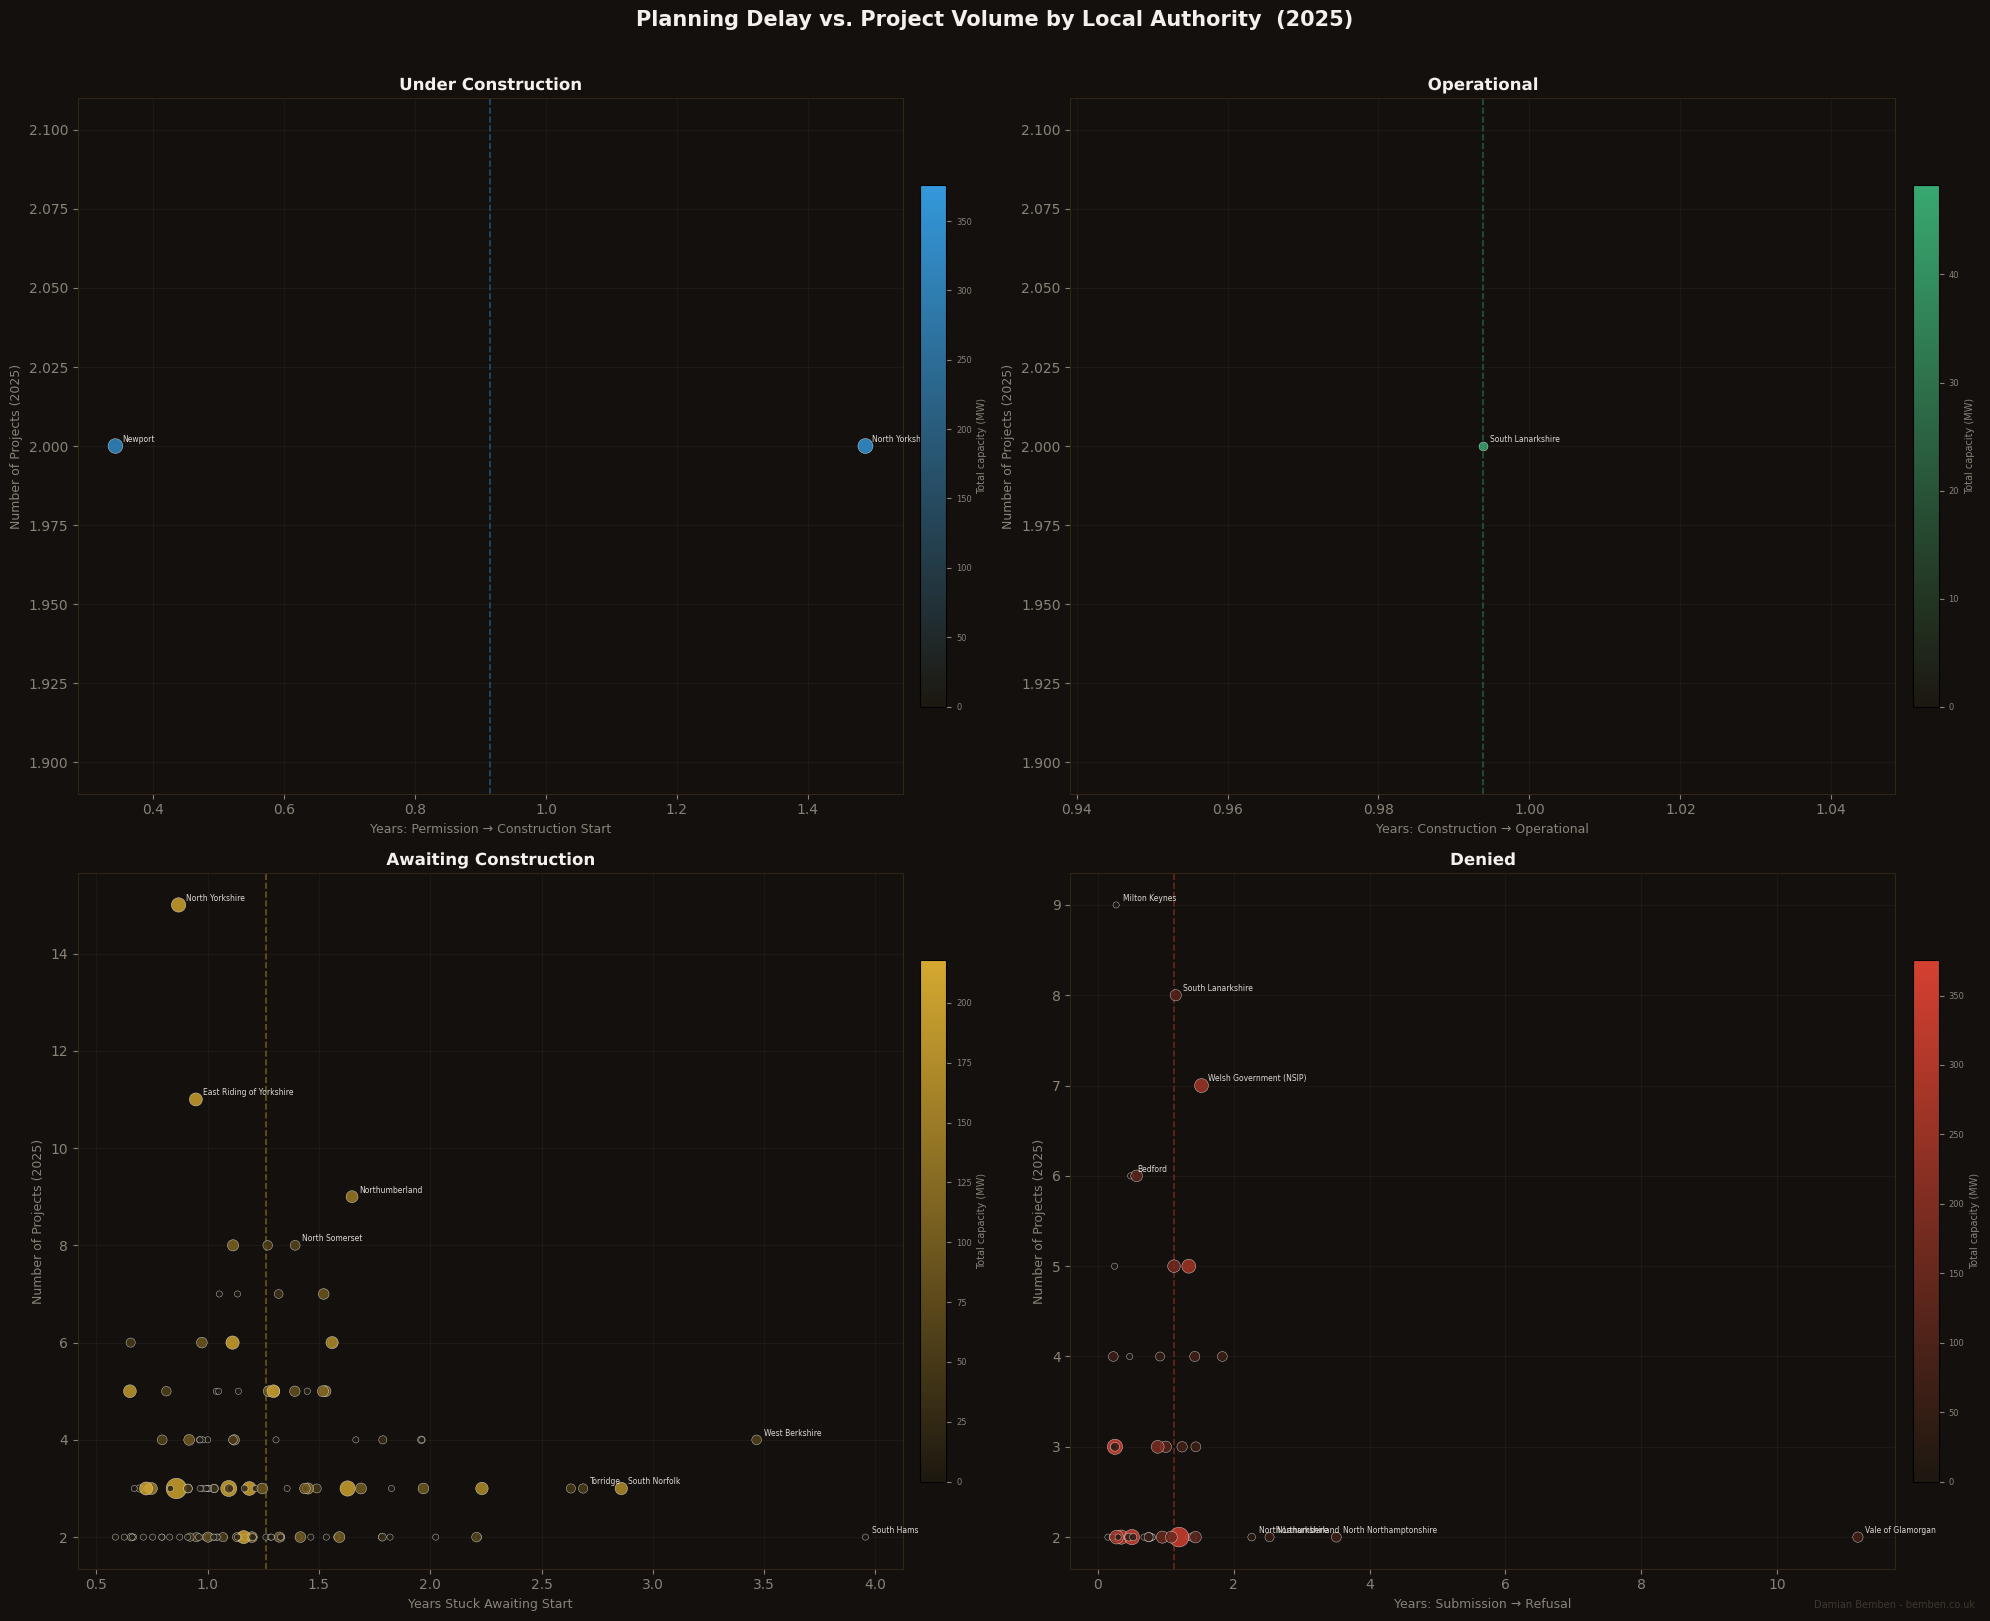

In [21]:
_panels = [
    (la_uc, 'Under Construction',    '#3498db', 'Years: Permission \u2192 Construction Start'),
    (la_op, 'Operational',           '#38a870', 'Years: Construction \u2192 Operational'),
    (la_aw, 'Awaiting Construction', '#d4a830', 'Years Stuck Awaiting Start'),
    (la_dn, 'Denied',                '#d44030', 'Years: Submission \u2192 Refusal'),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16), facecolor='#13100d')
axes = axes.flatten()

for ax, (agg, title, colour, xlabel) in zip(axes, _panels):
    ax.set_facecolor('#13100d')
    ax.tick_params(colors='#8a8278')
    for spine in ax.spines.values():
        spine.set_edgecolor('#332418')
    ax.set_axisbelow(True)

    if agg.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                ha='center', va='center', color='#8a8278', fontsize=11)
        ax.set_title(title, color='#f5f0eb', fontsize=12, fontweight='bold')
        continue

    sizes = np.clip(np.sqrt(agg['total_cap'].clip(lower=1)) * 6, 20, 500)
    norm  = mcolors.Normalize(vmin=0, vmax=max(agg['total_cap'].quantile(0.95), 1))
    cmap  = mcolors.LinearSegmentedColormap.from_list('panel', ['#1d1810', colour])
    cols  = [cmap(norm(v)) for v in agg['total_cap']]

    ax.scatter(agg['avg_delay'], agg['count'],
               s=sizes, c=cols, alpha=0.82,
               edgecolors='#ffffff', linewidths=0.3, zorder=3)

    # mean delay reference line
    ax.axvline(agg['avg_delay'].mean(), color=colour, linewidth=1.2,
               linestyle='--', alpha=0.45, zorder=2)

    # label top outliers: highest count + longest delay (deduplicated, up to 8)
    top_labels = pd.concat([
        agg.nlargest(4, 'count'),
        agg.nlargest(4, 'avg_delay'),
    ]).drop_duplicates('Planning Authority')
    for _, row in top_labels.iterrows():
        short = row['Planning Authority'][:24] + '\u2026' if len(row['Planning Authority']) > 24 else row['Planning Authority']
        ax.annotate(short, (row['avg_delay'], row['count']),
                    fontsize=5.5, color='#f5f0eb', alpha=0.9,
                    xytext=(5, 3), textcoords='offset points')

    ax.set_xlabel(xlabel, color='#8a8278', fontsize=9)
    ax.set_ylabel('Number of Projects (2025)', color='#8a8278', fontsize=9)
    ax.set_title(title, color='#f5f0eb', fontsize=12, fontweight='bold',
                 path_effects=[pe.withStroke(linewidth=2, foreground='#13100d')])
    ax.grid(color='#ffffff', alpha=0.05, linewidth=0.5)

    cb = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.03, pad=0.02
    )
    cb.set_label('Total capacity (MW)', color='#8a8278', fontsize=7)
    cb.ax.tick_params(colors='#8a8278', labelsize=6)

fig.suptitle('Planning Delay vs. Project Volume by Local Authority  (2025)',
             color='#f5f0eb', fontsize=15, fontweight='bold', y=1.01)
fig.text(0.99, 0.01, 'Damian Bemben - bemben.co.uk', ha='right', va='bottom',
         fontsize=7, color='#54483e', alpha=0.7)
plt.tight_layout()
plt.show()


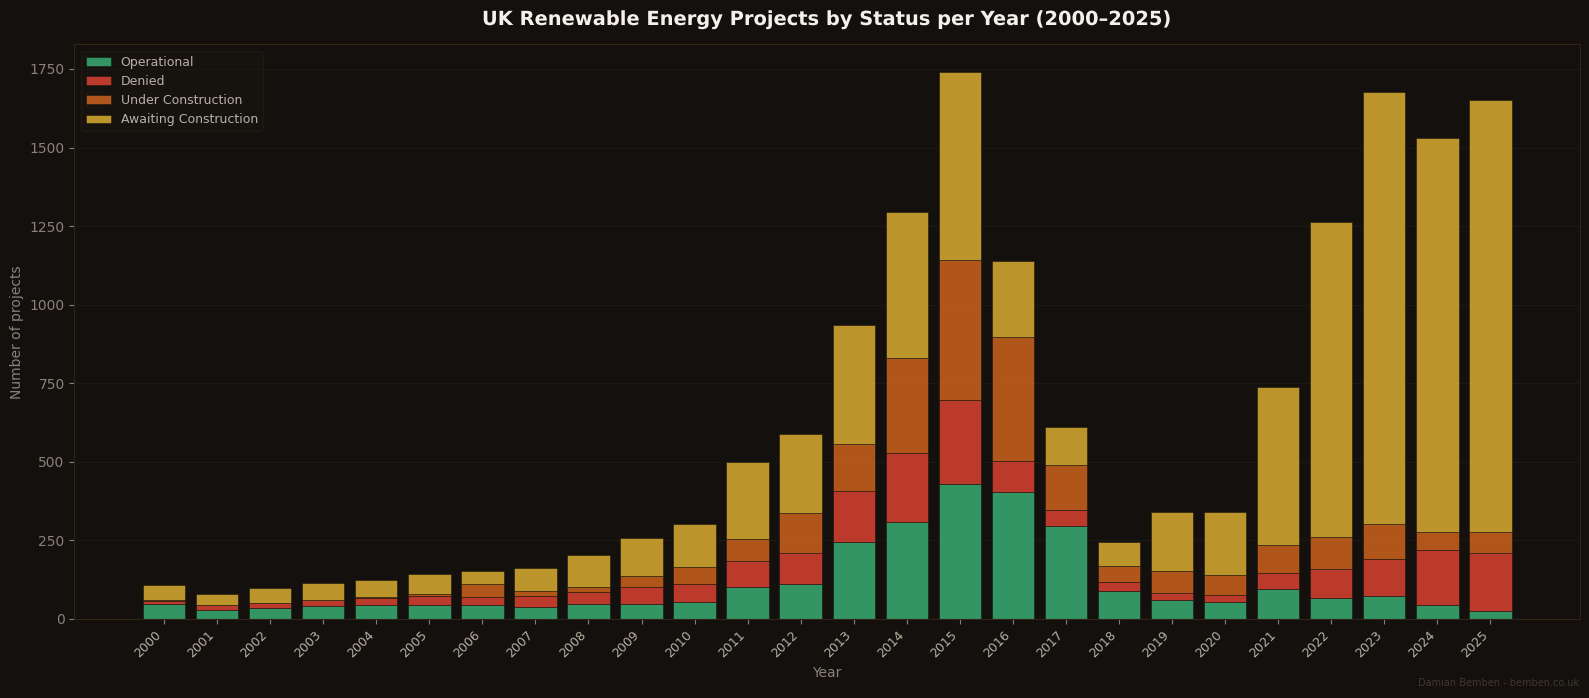

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# Parse additional date cols not yet parsed in the choropleth cell above
for _col in ["Planning Permission Refused", "Under Construction"]:
    repd_full[_col] = pd.to_datetime(repd_full[_col], dayfirst=True, errors="coerce")

# Count projects per year using the relevant event date for each status
_status_date_map = {
    "Operational":           "Operational",
    "Denied":                "Planning Permission Refused",
    "Under Construction":    "Under Construction",
    "Awaiting Construction": "Planning Permission Granted",
}

_frames = []
for _label, _col in _status_date_map.items():
    _yearly = (
        repd_full[repd_full[_col].notna()]
        .assign(_year=repd_full[_col].dt.year)
        .groupby("_year")
        .size()
        .rename(_label)
    )
    _yearly.index = _yearly.index.astype(int)
    _frames.append(_yearly)

_counts = pd.concat(_frames, axis=1).fillna(0).astype(int).sort_index().loc[2000:2025]

_palette = {
    "Operational":           "#38a870",
    "Denied":                "#d44030",
    "Under Construction":    "#c8601e",
    "Awaiting Construction": "#d4a830",
}

_years = _counts.index.tolist()
_x     = np.arange(len(_years))

fig, ax = plt.subplots(figsize=(16, 7), facecolor="#13100d")
ax.set_facecolor("#13100d")
ax.tick_params(colors="#8a8278")
for spine in ax.spines.values():
    spine.set_edgecolor("#332418")
ax.set_axisbelow(True)

_bottom = np.zeros(len(_years))
for _lbl, _color in _palette.items():
    _vals = _counts[_lbl].to_numpy()
    ax.bar(_x, _vals, bottom=_bottom, color=_color, label=_lbl,
           alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax.set_xticks(_x)
ax.set_xticklabels([str(y) for y in _years], color="#b8b0a6", fontsize=9, rotation=45, ha="right")
ax.set_xlabel("Year", color="#8a8278", fontsize=10)
ax.set_ylabel("Number of projects", color="#8a8278", fontsize=10)
ax.set_title(
    "UK Renewable Energy Projects by Status per Year (2000–2025)",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=14,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)
ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)
ax.legend(loc="upper left", fontsize=9, framealpha=0.4,
          facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")
fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()

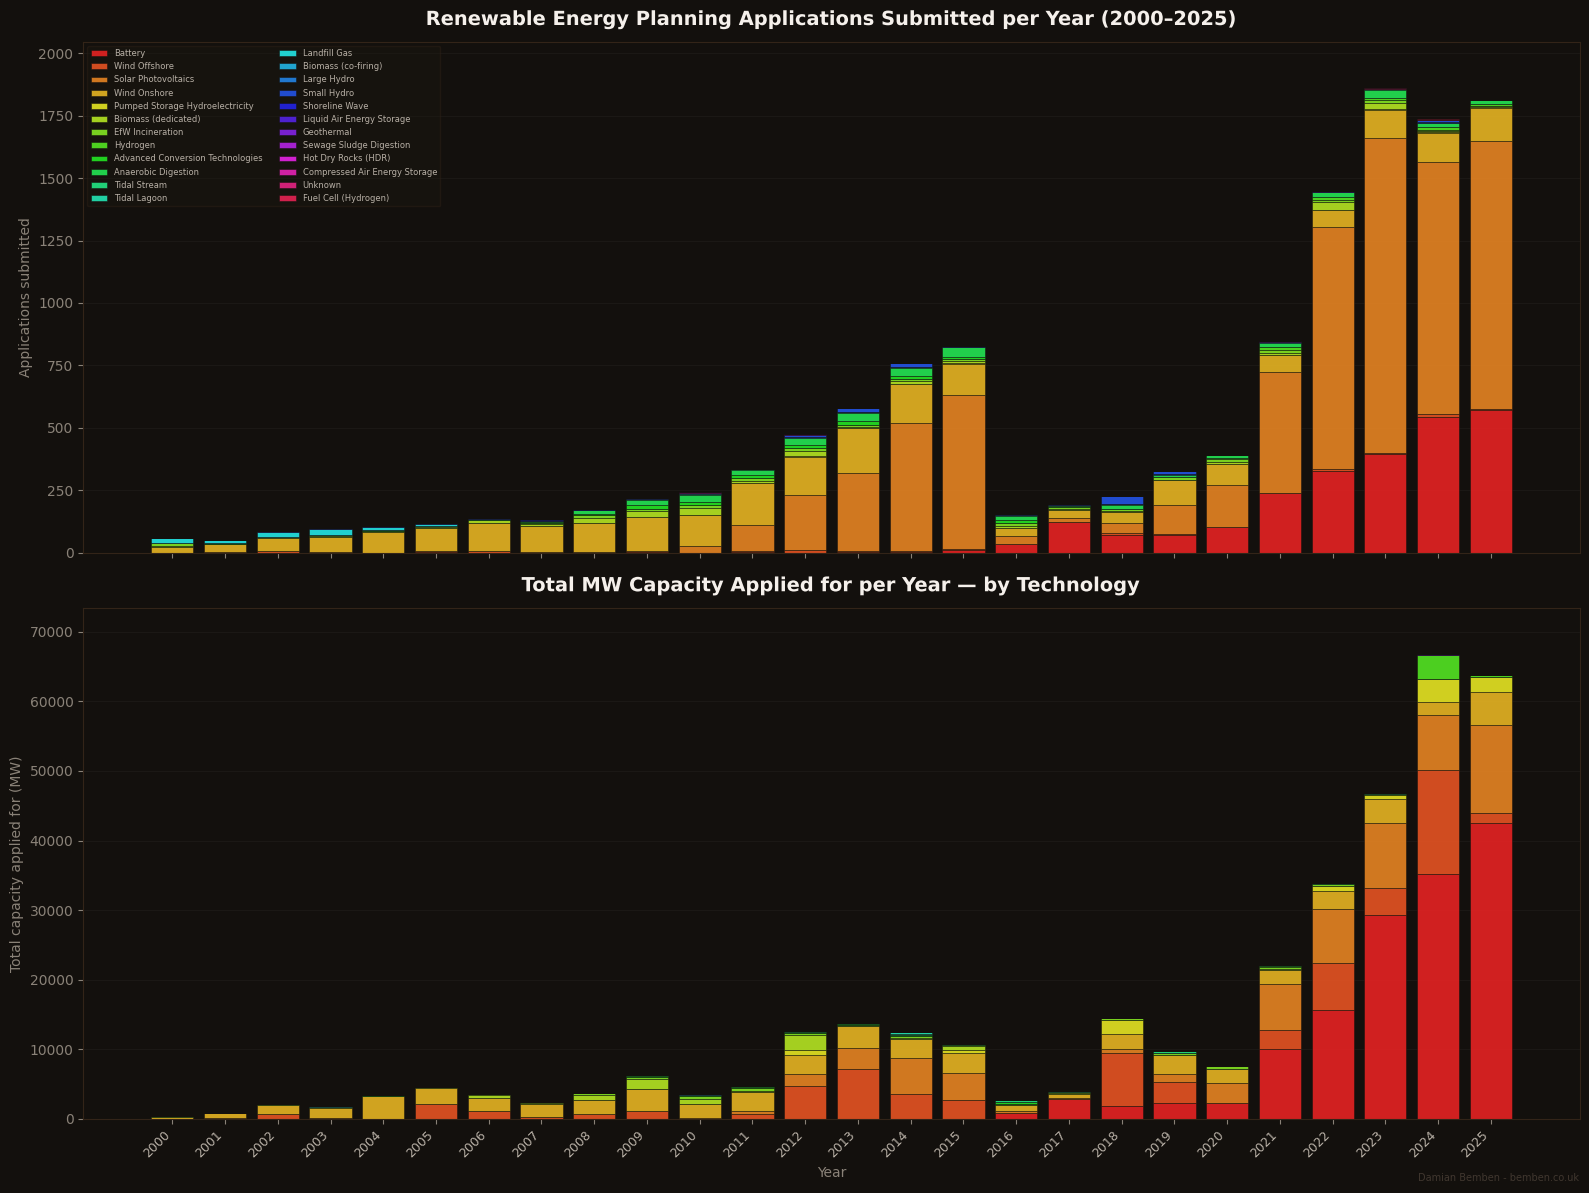

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Parse submission date and capacity
repd_full["Planning Application Submitted"] = pd.to_datetime(
    repd_full["Planning Application Submitted"], dayfirst=True, errors="coerce"
)
repd_full["Installed Capacity (MWelec)"] = pd.to_numeric(
    repd_full["Installed Capacity (MWelec)"], errors="coerce"
)

# Canonical colour map — derived from all records so every chart shares the same palette
_mw_by_tech = (
    repd_full.groupby("Technology Type")["Installed Capacity (MWelec)"]
    .sum()
    .sort_values(ascending=False)
)
_col_order   = _mw_by_tech.index.tolist()
_n           = len(_col_order)
_tech_colors = {t: mcolors.hsv_to_rgb((i / _n, 0.85, 0.92)) for i, t in enumerate(_col_order)}

# Base subset: submitted applications in 2000–2025
_sub = repd_full[repd_full["Planning Application Submitted"].notna()].copy()
_sub["_year"] = _sub["Planning Application Submitted"].dt.year.astype(int)
_sub = _sub[_sub["_year"].between(2000, 2025)]

# Count pivot
_count_pivot = (
    _sub.groupby(["_year", "Technology Type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)

# MW pivot
_mw_pivot = (
    _sub.groupby(["_year", "Technology Type"])["Installed Capacity (MWelec)"]
    .sum()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)

_count_pivot = _count_pivot.reindex(columns=_col_order, fill_value=0)
_mw_pivot    = _mw_pivot.reindex(columns=_col_order, fill_value=0)

_years = list(range(2000, 2026))
_x     = np.arange(len(_years))

# Shared axis limits (used by subsequent charts)
_shared_ymax_count = int(_count_pivot.sum(axis=1).max() * 1.1)
_shared_ymax_mw    = int(_mw_pivot.sum(axis=1).max() * 1.1)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 12), facecolor="#13100d", sharex=True)

def _style(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)

_style(ax_top)
_bottom = np.zeros(len(_years))
for _tech in _col_order:
    _vals = _count_pivot[_tech].to_numpy()
    ax_top.bar(_x, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_top.set_ylim(0, _shared_ymax_count)
ax_top.set_ylabel("Applications submitted", color="#8a8278", fontsize=10)
ax_top.set_title(
    "Renewable Energy Planning Applications Submitted per Year (2000–2025)",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)
_legend_handles = [mpatches.Patch(color=_tech_colors[t], label=t) for t in _col_order]
ax_top.legend(handles=_legend_handles, loc="upper left", fontsize=6, ncol=2, framealpha=0.4,
              facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

_style(ax_bot)
_bottom = np.zeros(len(_years))
for _tech in _col_order:
    _vals = _mw_pivot[_tech].to_numpy()
    ax_bot.bar(_x, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_bot.set_ylim(0, _shared_ymax_mw)
ax_bot.set_xticks(_x)
ax_bot.set_xticklabels([str(y) for y in _years], color="#b8b0a6", fontsize=9, rotation=45, ha="right")
ax_bot.set_xlabel("Year", color="#8a8278", fontsize=10)
ax_bot.set_ylabel("Total capacity applied for (MW)", color="#8a8278", fontsize=10)
ax_bot.set_title(
    "Total MW Capacity Applied for per Year — by Technology",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


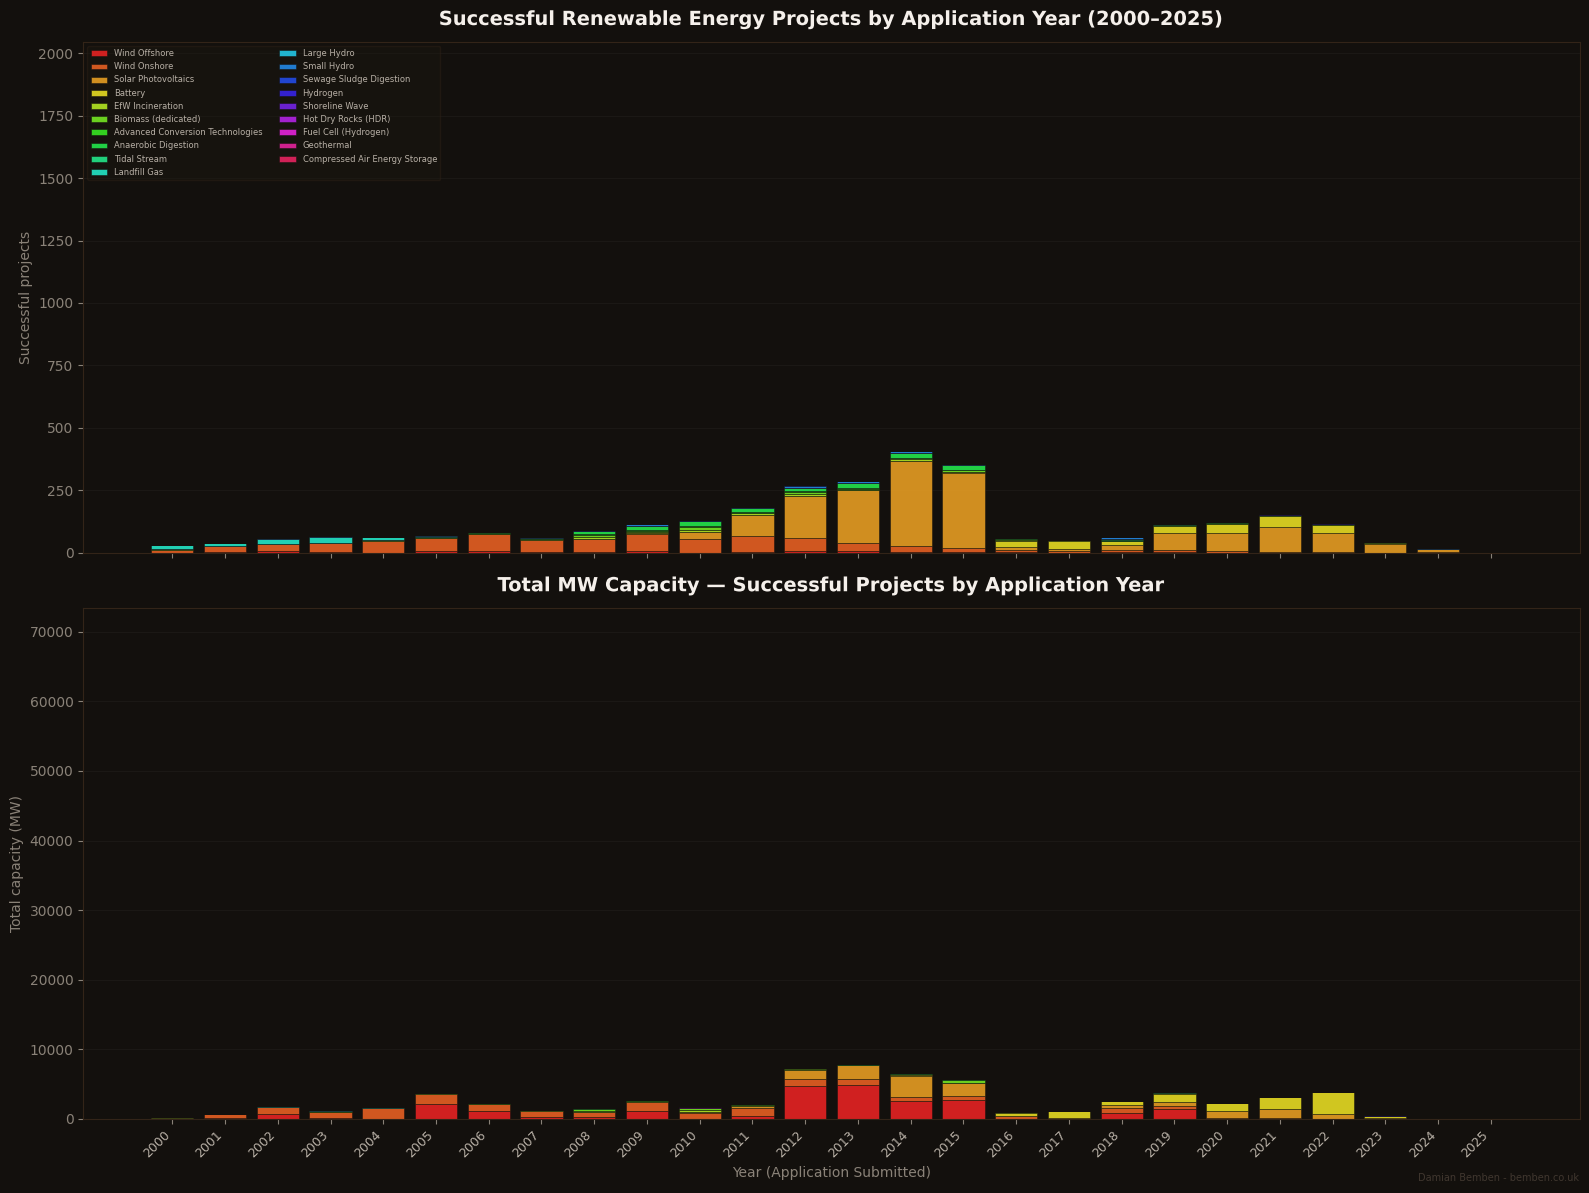

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

repd_full["Planning Application Submitted"] = pd.to_datetime(
    repd_full["Planning Application Submitted"], dayfirst=True, errors="coerce"
)
repd_full["Installed Capacity (MWelec)"] = pd.to_numeric(
    repd_full["Installed Capacity (MWelec)"], errors="coerce"
)

_sub_suc = repd_full[
    repd_full["Development Status (short)"].isin(SUCCESSFUL_DEVELOPMENT_TYPES)
    & repd_full["Planning Application Submitted"].notna()
].copy()
_sub_suc["_year"] = _sub_suc["Planning Application Submitted"].dt.year.astype(int)
_sub_suc = _sub_suc[_sub_suc["_year"].between(2000, 2025)]

_count_pivot_suc = (
    _sub_suc.groupby(["_year", "Technology Type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)
_mw_pivot_suc = (
    _sub_suc.groupby(["_year", "Technology Type"])["Installed Capacity (MWelec)"]
    .sum()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)

# Use the same column order and colours as the all-submissions chart
_count_pivot_suc = _count_pivot_suc.reindex(columns=_col_order, fill_value=0)
_mw_pivot_suc    = _mw_pivot_suc.reindex(columns=_col_order, fill_value=0)

_years_suc = list(range(2000, 2026))
_x_suc     = np.arange(len(_years_suc))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 12), facecolor="#13100d", sharex=True)

def _style(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)

_style(ax_top)
_bottom = np.zeros(len(_years_suc))
for _tech in _col_order:
    _vals = _count_pivot_suc[_tech].to_numpy()
    ax_top.bar(_x_suc, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_top.set_ylim(0, _shared_ymax_count)
ax_top.set_ylabel("Successful projects", color="#8a8278", fontsize=10)
ax_top.set_title(
    "Successful Renewable Energy Projects by Application Year (2000–2025)",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)
_legend_handles = [mpatches.Patch(color=_tech_colors[t], label=t) for t in _col_order]
ax_top.legend(handles=_legend_handles, loc="upper left", fontsize=6, ncol=2, framealpha=0.4,
              facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

_style(ax_bot)
_bottom = np.zeros(len(_years_suc))
for _tech in _col_order:
    _vals = _mw_pivot_suc[_tech].to_numpy()
    ax_bot.bar(_x_suc, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_bot.set_ylim(0, _shared_ymax_mw)
ax_bot.set_xticks(_x_suc)
ax_bot.set_xticklabels([str(y) for y in _years_suc], color="#b8b0a6", fontsize=9, rotation=45, ha="right")
ax_bot.set_xlabel("Year (Application Submitted)", color="#8a8278", fontsize=10)
ax_bot.set_ylabel("Total capacity (MW)", color="#8a8278", fontsize=10)
ax_bot.set_title(
    "Total MW Capacity — Successful Projects by Application Year",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


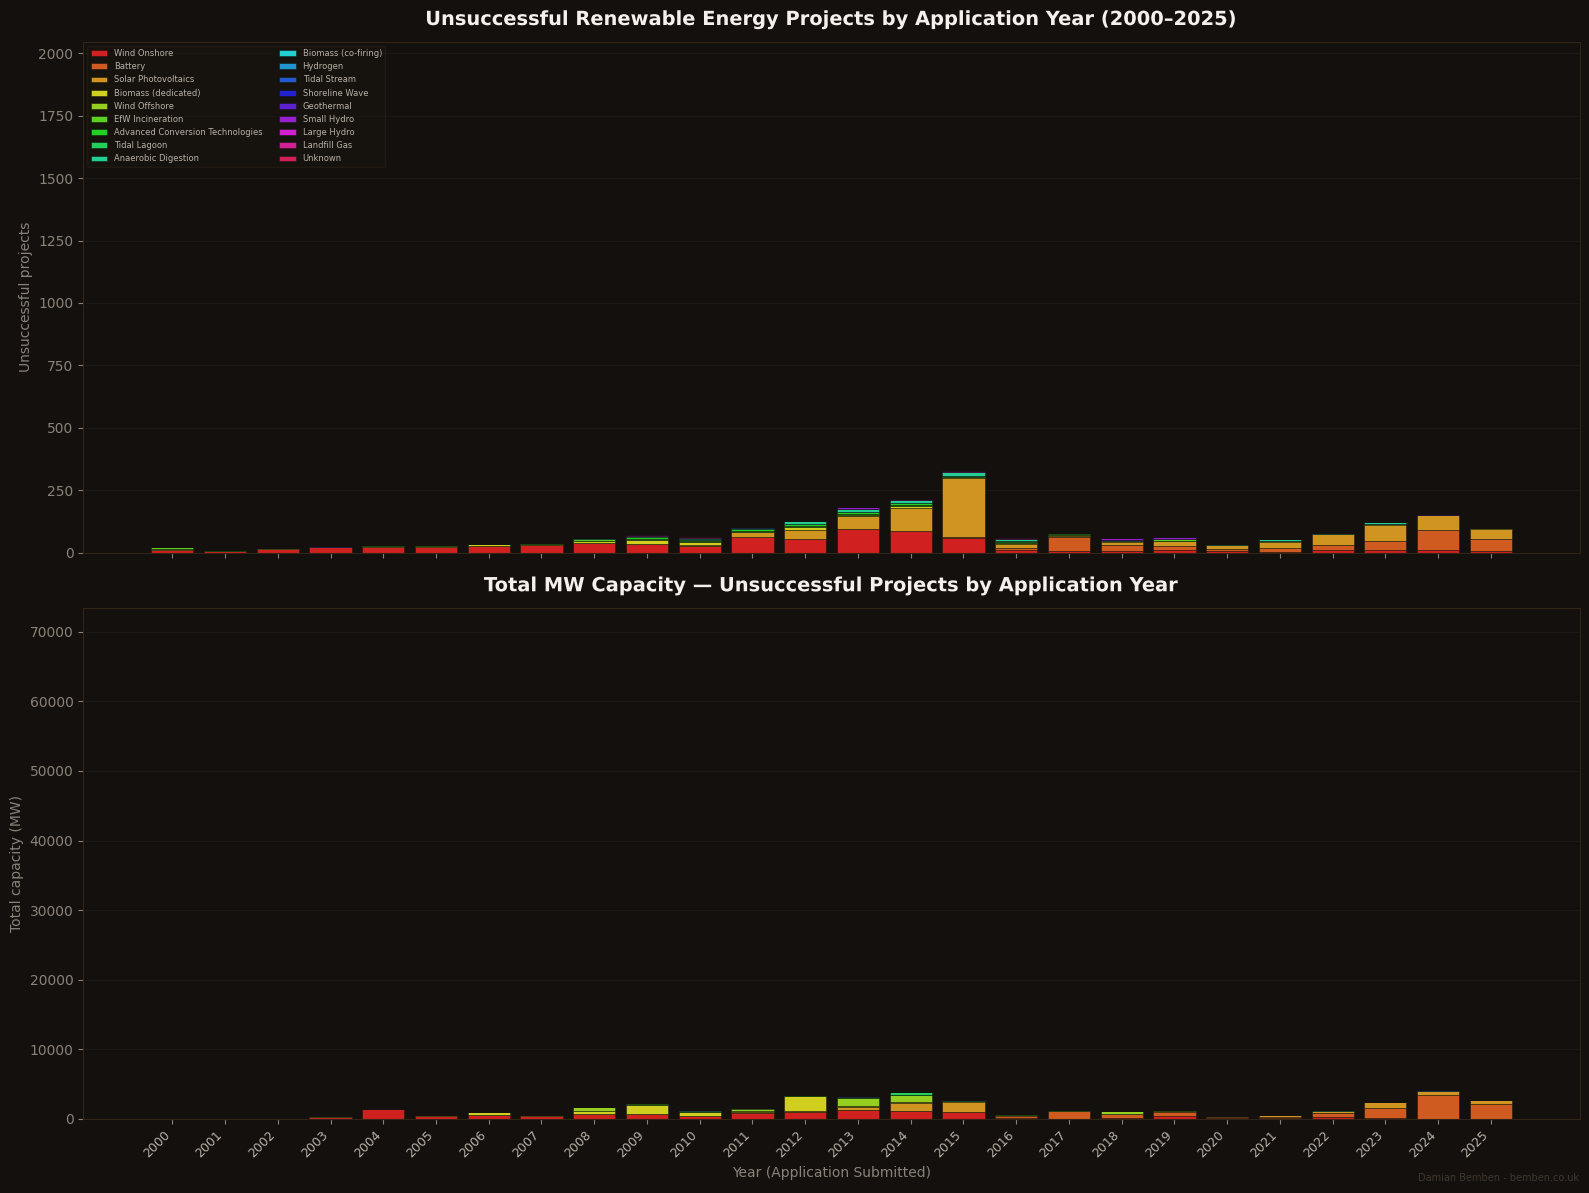

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

repd_full["Planning Application Submitted"] = pd.to_datetime(
    repd_full["Planning Application Submitted"], dayfirst=True, errors="coerce"
)
repd_full["Installed Capacity (MWelec)"] = pd.to_numeric(
    repd_full["Installed Capacity (MWelec)"], errors="coerce"
)

_sub_fail = repd_full[
    repd_full["Development Status (short)"].isin(UNSUCCESSFUL_DEVELOPMENT_TYPES)
    & repd_full["Planning Application Submitted"].notna()
].copy()
_sub_fail["_year"] = _sub_fail["Planning Application Submitted"].dt.year.astype(int)
_sub_fail = _sub_fail[_sub_fail["_year"].between(2000, 2025)]

_count_pivot_fail = (
    _sub_fail.groupby(["_year", "Technology Type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)
_mw_pivot_fail = (
    _sub_fail.groupby(["_year", "Technology Type"])["Installed Capacity (MWelec)"]
    .sum()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)

# Use the same column order and colours as the all-submissions chart
_count_pivot_fail = _count_pivot_fail.reindex(columns=_col_order, fill_value=0)
_mw_pivot_fail    = _mw_pivot_fail.reindex(columns=_col_order, fill_value=0)

_years_fail = list(range(2000, 2026))
_x_fail     = np.arange(len(_years_fail))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 12), facecolor="#13100d", sharex=True)

def _style(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)

_style(ax_top)
_bottom = np.zeros(len(_years_fail))
for _tech in _col_order:
    _vals = _count_pivot_fail[_tech].to_numpy()
    ax_top.bar(_x_fail, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_top.set_ylim(0, _shared_ymax_count)
ax_top.set_ylabel("Unsuccessful projects", color="#8a8278", fontsize=10)
ax_top.set_title(
    "Unsuccessful Renewable Energy Projects by Application Year (2000–2025)",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)
_legend_handles = [mpatches.Patch(color=_tech_colors[t], label=t) for t in _col_order]
ax_top.legend(handles=_legend_handles, loc="upper left", fontsize=6, ncol=2, framealpha=0.4,
              facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

_style(ax_bot)
_bottom = np.zeros(len(_years_fail))
for _tech in _col_order:
    _vals = _mw_pivot_fail[_tech].to_numpy()
    ax_bot.bar(_x_fail, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_bot.set_ylim(0, _shared_ymax_mw)
ax_bot.set_xticks(_x_fail)
ax_bot.set_xticklabels([str(y) for y in _years_fail], color="#b8b0a6", fontsize=9, rotation=45, ha="right")
ax_bot.set_xlabel("Year (Application Submitted)", color="#8a8278", fontsize=10)
ax_bot.set_ylabel("Total capacity (MW)", color="#8a8278", fontsize=10)
ax_bot.set_title(
    "Total MW Capacity — Unsuccessful Projects by Application Year",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


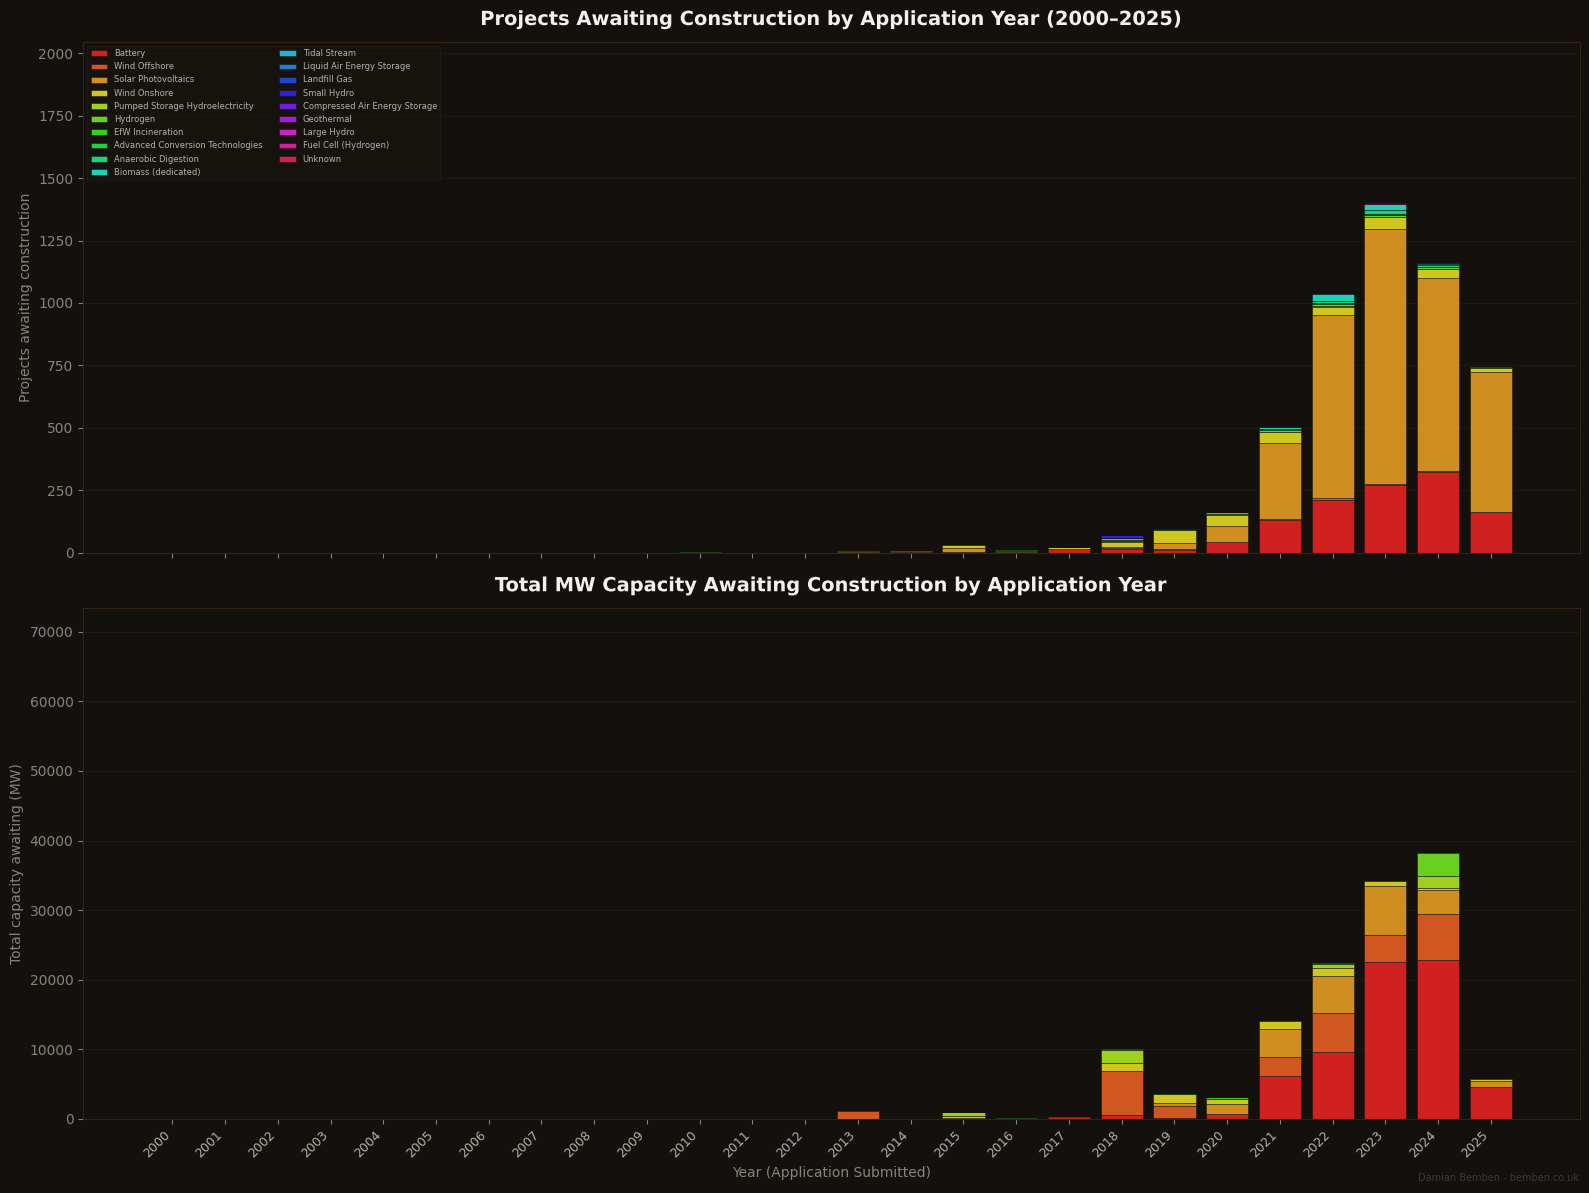

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

repd_full["Planning Application Submitted"] = pd.to_datetime(
    repd_full["Planning Application Submitted"], dayfirst=True, errors="coerce"
)
repd_full["Installed Capacity (MWelec)"] = pd.to_numeric(
    repd_full["Installed Capacity (MWelec)"], errors="coerce"
)

_sub_aw = repd_full[
    (repd_full["Development Status (short)"] == "Awaiting Construction")
    & repd_full["Planning Application Submitted"].notna()
].copy()
_sub_aw["_year"] = _sub_aw["Planning Application Submitted"].dt.year.astype(int)
_sub_aw = _sub_aw[_sub_aw["_year"].between(2000, 2025)]

_count_pivot_aw = (
    _sub_aw.groupby(["_year", "Technology Type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)
_mw_pivot_aw = (
    _sub_aw.groupby(["_year", "Technology Type"])["Installed Capacity (MWelec)"]
    .sum()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)

# Use the same column order and colours as the all-submissions chart
_count_pivot_aw = _count_pivot_aw.reindex(columns=_col_order, fill_value=0)
_mw_pivot_aw    = _mw_pivot_aw.reindex(columns=_col_order, fill_value=0)

_years_aw = list(range(2000, 2026))
_x_aw     = np.arange(len(_years_aw))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 12), facecolor="#13100d", sharex=True)

def _style(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)

_style(ax_top)
_bottom = np.zeros(len(_years_aw))
for _tech in _col_order:
    _vals = _count_pivot_aw[_tech].to_numpy()
    ax_top.bar(_x_aw, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_top.set_ylim(0, _shared_ymax_count)
ax_top.set_ylabel("Projects awaiting construction", color="#8a8278", fontsize=10)
ax_top.set_title(
    "Projects Awaiting Construction by Application Year (2000–2025)",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)
_legend_handles = [mpatches.Patch(color=_tech_colors[t], label=t) for t in _col_order]
ax_top.legend(handles=_legend_handles, loc="upper left", fontsize=6, ncol=2, framealpha=0.4,
              facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

_style(ax_bot)
_bottom = np.zeros(len(_years_aw))
for _tech in _col_order:
    _vals = _mw_pivot_aw[_tech].to_numpy()
    ax_bot.bar(_x_aw, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_bot.set_ylim(0, _shared_ymax_mw)
ax_bot.set_xticks(_x_aw)
ax_bot.set_xticklabels([str(y) for y in _years_aw], color="#b8b0a6", fontsize=9, rotation=45, ha="right")
ax_bot.set_xlabel("Year (Application Submitted)", color="#8a8278", fontsize=10)
ax_bot.set_ylabel("Total capacity awaiting (MW)", color="#8a8278", fontsize=10)
ax_bot.set_title(
    "Total MW Capacity Awaiting Construction by Application Year",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


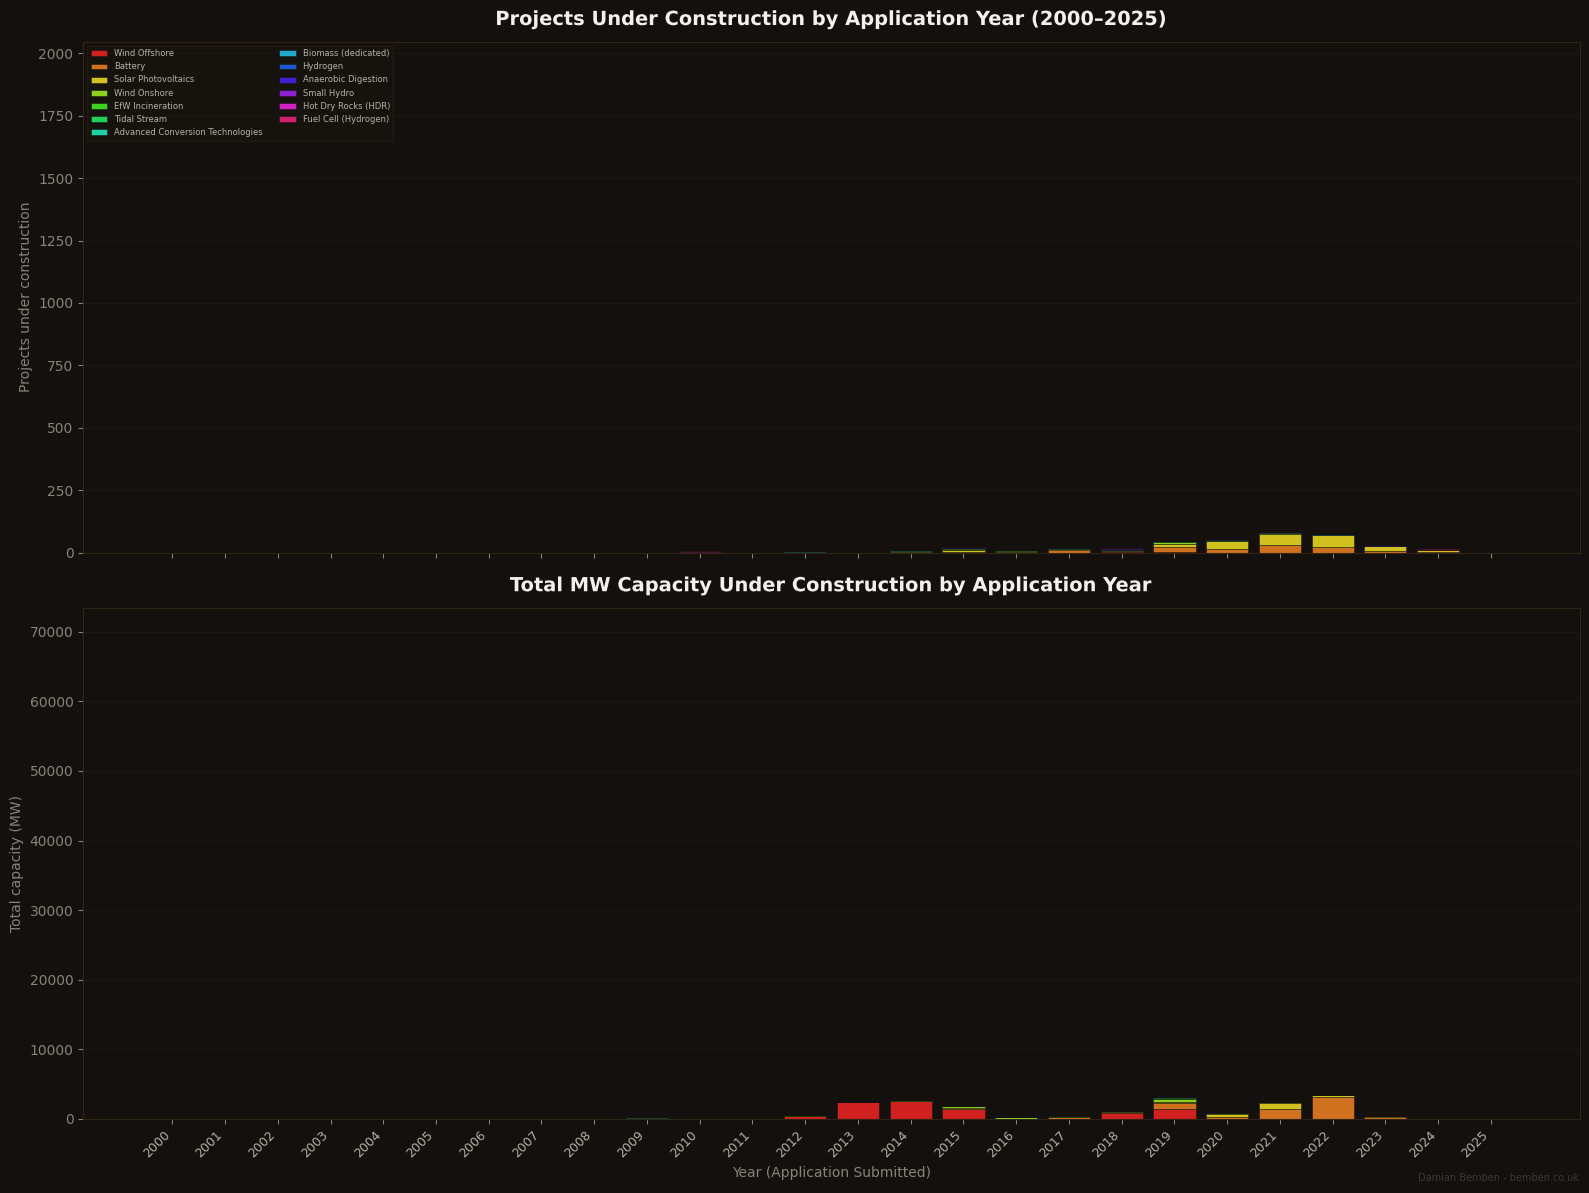

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

repd_full["Planning Application Submitted"] = pd.to_datetime(
    repd_full["Planning Application Submitted"], dayfirst=True, errors="coerce"
)
repd_full["Installed Capacity (MWelec)"] = pd.to_numeric(
    repd_full["Installed Capacity (MWelec)"], errors="coerce"
)

_sub_uc = repd_full[
    (repd_full["Development Status (short)"] == "Under Construction")
    & repd_full["Planning Application Submitted"].notna()
].copy()
_sub_uc["_year"] = _sub_uc["Planning Application Submitted"].dt.year.astype(int)
_sub_uc = _sub_uc[_sub_uc["_year"].between(2000, 2025)]

_count_pivot_uc = (
    _sub_uc.groupby(["_year", "Technology Type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)
_mw_pivot_uc = (
    _sub_uc.groupby(["_year", "Technology Type"])["Installed Capacity (MWelec)"]
    .sum()
    .unstack(fill_value=0)
    .reindex(range(2000, 2026), fill_value=0)
)

# Use the same column order and colours as the all-submissions chart
_count_pivot_uc = _count_pivot_uc.reindex(columns=_col_order, fill_value=0)
_mw_pivot_uc    = _mw_pivot_uc.reindex(columns=_col_order, fill_value=0)

_years_uc = list(range(2000, 2026))
_x_uc     = np.arange(len(_years_uc))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 12), facecolor="#13100d", sharex=True)

def _style(ax):
    ax.set_facecolor("#13100d")
    ax.tick_params(colors="#8a8278")
    for spine in ax.spines.values():
        spine.set_edgecolor("#332418")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#ffffff", alpha=0.05, linewidth=0.5)

_style(ax_top)
_bottom = np.zeros(len(_years_uc))
for _tech in _col_order:
    _vals = _count_pivot_uc[_tech].to_numpy()
    ax_top.bar(_x_uc, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_top.set_ylim(0, _shared_ymax_count)
ax_top.set_ylabel("Projects under construction", color="#8a8278", fontsize=10)
ax_top.set_title(
    "Projects Under Construction by Application Year (2000–2025)",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)
_legend_handles = [mpatches.Patch(color=_tech_colors[t], label=t) for t in _col_order]
ax_top.legend(handles=_legend_handles, loc="upper left", fontsize=6, ncol=2, framealpha=0.4,
              facecolor="#1d1810", edgecolor="#332418", labelcolor="#b8b0a6")

_style(ax_bot)
_bottom = np.zeros(len(_years_uc))
for _tech in _col_order:
    _vals = _mw_pivot_uc[_tech].to_numpy()
    ax_bot.bar(_x_uc, _vals, bottom=_bottom, color=_tech_colors[_tech], label=_tech,
               alpha=0.88, edgecolor="#13100d", linewidth=0.4)
    _bottom += _vals

ax_bot.set_ylim(0, _shared_ymax_mw)
ax_bot.set_xticks(_x_uc)
ax_bot.set_xticklabels([str(y) for y in _years_uc], color="#b8b0a6", fontsize=9, rotation=45, ha="right")
ax_bot.set_xlabel("Year (Application Submitted)", color="#8a8278", fontsize=10)
ax_bot.set_ylabel("Total capacity (MW)", color="#8a8278", fontsize=10)
ax_bot.set_title(
    "Total MW Capacity Under Construction by Application Year",
    color="#f5f0eb", fontsize=14, fontweight="bold", pad=12,
    path_effects=[pe.withStroke(linewidth=3, foreground="#13100d")],
)

fig.text(0.99, 0.01, "Damian Bemben - bemben.co.uk", ha="right", va="bottom",
         fontsize=7, color="#54483e", alpha=0.7)
plt.tight_layout()
plt.show()


In [28]:
# ── Capacity sanity check ─────────────────────────────────────────────────────
print("=== Capacity distribution (MWelec, all submitted projects) ===")
print(_sub["Installed Capacity (MWelec)"].describe().round(1))

print("\n=== Top 15 projects by capacity ===")
print(
    _sub[["Site Name", "Technology Type", "_year", "Installed Capacity (MWelec)",
          "Development Status (short)"]]
    .sort_values("Installed Capacity (MWelec)", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\n=== Total MW submitted per year (all techs) ===")
print(_mw_pivot.sum(axis=1).rename("total_MW").astype(int).to_string())

=== Capacity distribution (MWelec, all submitted projects) ===
count    12177.0
mean        29.5
std        122.6
min          0.0
25%          0.5
50%          5.0
75%         20.0
max       4100.0
Name: Installed Capacity (MWelec), dtype: float64

=== Top 15 projects by capacity ===
                                             Site Name                 Technology Type  _year  Installed Capacity (MWelec) Development Status (short)
                      Berwick Bank Offshore Wind Farm                    Wind Offshore   2022                       4100.0      Awaiting Construction
                                                Ossian                   Wind Offshore   2024                       3600.0      Awaiting Construction
The Kintore Hydrogen Project, Kintore - Hydrogen Plant                        Hydrogen   2024                       3000.0      Awaiting Construction
                                             Hornsea 3                   Wind Offshore   2018                     